# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [38]:
!pip install mat73 h5py

In [39]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [40]:
# ── 경로 설정  ─────────────────────────────
DATA_DIR = "./archive"  

batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
batch2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
batch3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

BATCH_PATHS = {
    1: batch1_path,
    2: batch2_path,
    3: batch3_path,
}

## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [41]:
def load_mat(path):
    """MATLAB v7.3(HDF5) 또는 v7.2 이하 .mat 파일 로더."""
    try:
        data = mat73.loadmat(path)
        print("  ✔ mat73 (v7.3 / HDF5)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("  ✔ scipy (v7.2 이하)")
    return data


def normalize_batch(mat):
    """mat73 dict-of-lists → list of dicts 정규화."""
    batch = mat['batch']
    if isinstance(batch, dict):
        keys  = list(batch.keys())
        n     = len(batch[keys[0]])
        batch = [{k: batch[k][i] for k in keys} for i in range(n)]
    return batch


def to_list_of_dicts(d):
    """mat73 dict-of-lists → list of dicts (cycles 등 내부 필드용)."""
    if isinstance(d, dict):
        keys = list(d.keys())
        n    = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d


# ── 배치 로드 ──────────────────────────────────────────────────
all_batches = {}   # {batch_id: list of cell dicts}

for bid, path in BATCH_PATHS.items():
    print(f"\n[Batch {bid}] 로딩 중... ({path})")
    if not os.path.exists(path):
        print(f"  ⚠  파일 없음 — 건너뜀")
        continue
    mat = load_mat(path)
    all_batches[bid] = normalize_batch(mat)
    print(f"  셀 수 : {len(all_batches[bid])}")

print(f"\n로드 완료 배치 : {list(all_batches.keys())}")


[Batch 1] 로딩 중... (./archive/2017-05-12_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

  ✔ mat73 (v7.3 / HDF5)
  셀 수 : 46

[Batch 2] 로딩 중... (./archive/2018-02-20_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

  ✔ mat73 (v7.3 / HDF5)
  셀 수 : 47

[Batch 3] 로딩 중... (./archive/2018-04-12_batchdata_updated_struct_errorcorrect.mat)
  ✔ mat73 (v7.3 / HDF5)
  셀 수 : 46

로드 완료 배치 : [1, 2, 3]


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [42]:
def extract_summary(batch, batch_id):
    """batch list → 사이클별 summary DataFrame."""
    records = []
    for local_i, cell_data in enumerate(batch):
        summary = cell_data.get('summary')
        if summary is None:
            continue
        try:
            cycle_life = int(cell_data['cycle_life'])
        except Exception:
            continue

        policy = str(
            cell_data.get('policy_readable') or
            cell_data.get('policy') or 'unknown'
        )

        if isinstance(summary, dict):
            qd   = np.array(summary.get('QDischarge', summary.get('QD', [])))
            qc   = np.array(summary.get('QCharge',    []))
            ir   = np.array(summary.get('IR',         []))
            tmax = np.array(summary.get('Tmax',       []))
            tavg = np.array(summary.get('Tavg',       []))
            tmin = np.array(summary.get('Tmin',       []))
            ct   = np.array(summary.get('chargetime', []))
        else:
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])

        n = len(qd)
        for c in range(n):
            records.append({
                'batch_id'       : batch_id,
                'local_cell_id'  : local_i,
                'cell_id'        : f"b{batch_id}_c{local_i}",
                'cycle'          : c + 1,
                'cycle_life'     : cycle_life,
                'charging_policy': policy,
                'QD'             : float(qd[c])   if c < len(qd)   else np.nan,
                'QC'             : float(qc[c])   if c < len(qc)   else np.nan,
                'IR'             : float(ir[c])   if c < len(ir)   else np.nan,
                'Tmax'           : float(tmax[c]) if c < len(tmax) else np.nan,
                'Tavg'           : float(tavg[c]) if c < len(tavg) else np.nan,
                'Tmin'           : float(tmin[c]) if c < len(tmin) else np.nan,
                'chargetime'     : float(ct[c])   if c < len(ct)   else np.nan,
            })
    return pd.DataFrame(records)


# ── 전체 배치 통합 ─────────────────────────────────────────────
df_list = []
for bid, batch in all_batches.items():
    tmp = extract_summary(batch, bid)
    df_list.append(tmp)
    print(f"Batch {bid}: {tmp['cell_id'].nunique()} cells, {len(tmp):,} rows")

df = pd.concat(df_list, ignore_index=True)
print(f"\n전체 DataFrame shape : {df.shape}")
df.head()

Batch 1: 46 cells, 38,811 rows
Batch 2: 39 cells, 23,034 rows
Batch 3: 44 cells, 46,581 rows

전체 DataFrame shape : (108426, 13)


,batch_id,local_cell_id,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,1,0,b1_c0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0,b1_c0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,1,0,b1_c0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,1,0,b1_c0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,1,0,b1_c0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [43]:
print("=== 기본 통계 ===")
print(df.describe().round(3))
print("\n=== 결측치 ===")
print(df.isnull().sum())
print(f"\n배치별 셀 수:")
print(df.groupby('batch_id')['cell_id'].nunique())

=== 기본 통계 ===
         batch_id  local_cell_id       cycle  cycle_life          QD  \
count  108426.000     108426.000  108426.000  108426.000  108426.000   
mean        2.072         22.120     477.555     948.947       1.039   
std         0.885         13.881     338.194     343.328       0.056   
min         1.000          0.000       1.000     392.000       0.000   
25%         1.000         10.000     211.000     742.000       1.023   
50%         2.000         21.000     421.000     902.000       1.054   
75%         3.000         34.000     687.000    1140.000       1.072   
max         3.000         46.000    1934.000    1935.000       2.884   

               QC          IR        Tmax        Tavg        Tmin  chargetime  
count  108426.000  108426.000  108426.000  108426.000  108426.000  108426.000  
mean        1.038       0.016      37.767      34.261      31.465      11.273  
std         0.055       0.003       2.677       2.037       1.615      37.792  
min         0.000

## EDA(Basic)

### 1. Cycle Life 분포

In [44]:
cycle_life_df = df.drop_duplicates('cell_id')[
    ['batch_id', 'cell_id', 'local_cell_id', 'cycle_life', 'charging_policy']
].reset_index(drop=True)

print(f"전체 셀 수 : {len(cycle_life_df)}")
print(f"배치별:")
print(cycle_life_df.groupby('batch_id')['cell_id'].count())
cycle_life_df.head()

전체 셀 수 : 129
배치별:
batch_id
1    46
2    39
3    44
Name: cell_id, dtype: int64


,batch_id,cell_id,local_cell_id,cycle_life,charging_policy
0,1,b1_c0,0,1190,3.6C(80%)-3.6C
1,1,b1_c1,1,1179,3.6C(80%)-3.6C
2,1,b1_c2,2,1177,3.6C(80%)-3.6C
3,1,b1_c3,3,1226,4C(80%)-4C
4,1,b1_c4,4,1227,4C(80%)-4C


1. Cycle Life 분포 시각화

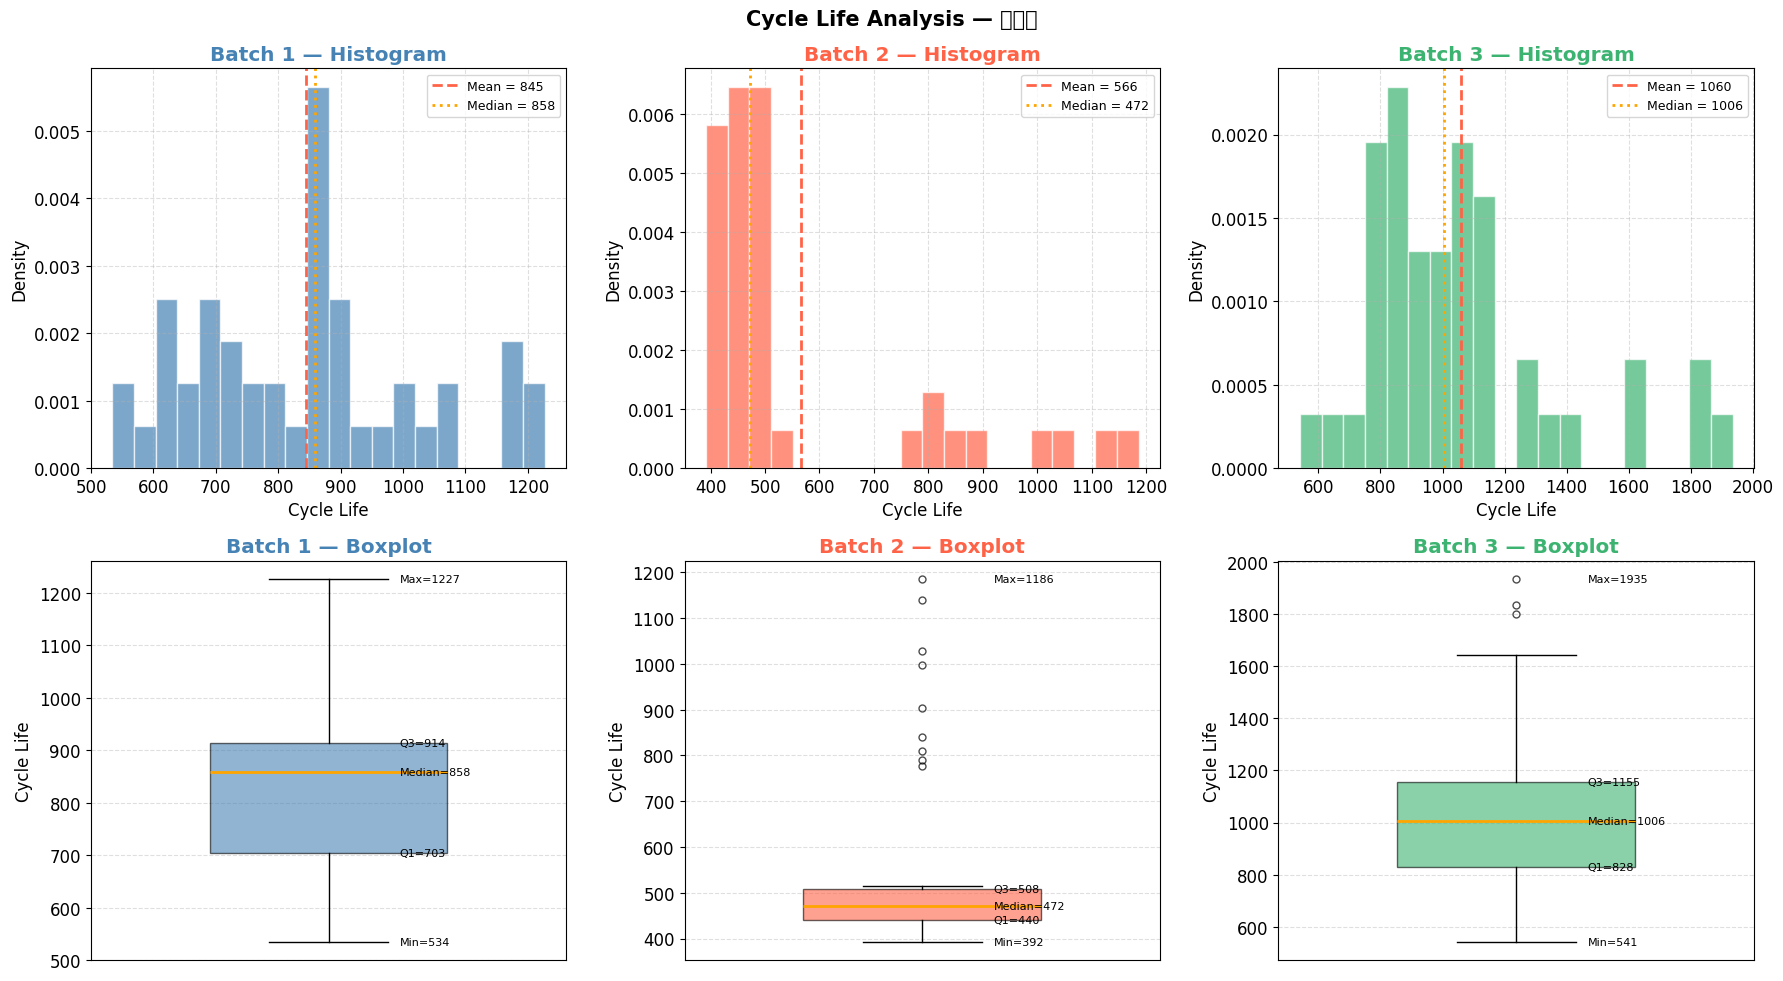

  Cycle Life 기술통계 — 배치별

[Batch 1]  (n=46)
count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0

[Batch 2]  (n=39)
count      39.0
mean      565.7
std       222.2
min       392.0
25%       439.5
50%       472.0
75%       508.5
max      1186.0

[Batch 3]  (n=44)
count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0


In [45]:
batch_ids    = sorted(cycle_life_df['batch_id'].unique())
batch_colors = {1: 'steelblue', 2: 'tomato', 3: 'mediumseagreen'}
n_batches    = len(batch_ids)

fig, axes = plt.subplots(2, n_batches, figsize=(6 * n_batches, 10))
if n_batches == 1:
    axes = axes.reshape(2, 1)

fig.suptitle('Cycle Life Analysis — 배치별', fontsize=15, fontweight='bold')

for col, bid in enumerate(batch_ids):
    sub   = cycle_life_df[cycle_life_df['batch_id'] == bid]['cycle_life']
    color = batch_colors.get(bid, 'gray')

    # ── 위: 히스토그램 ───────────────────────────────────────────
    ax_h = axes[0][col]
    ax_h.hist(sub, bins=20, density=True, alpha=0.7,
              color=color, edgecolor='white')
    ax_h.axvline(sub.mean(), color='tomato', linestyle='--', linewidth=2,
                 label=f'Mean = {sub.mean():.0f}')
    ax_h.axvline(sub.median(), color='orange', linestyle=':', linewidth=2,
                 label=f'Median = {sub.median():.0f}')
    ax_h.set_title(f'Batch {bid} — Histogram', fontweight='bold', color=color)
    ax_h.set_xlabel('Cycle Life')
    ax_h.set_ylabel('Density')
    ax_h.legend(fontsize=9)
    ax_h.grid(True, linestyle='--', alpha=0.4)

    # ── 아래: 박스플롯 ───────────────────────────────────────────
    ax_b = axes[1][col]
    bp   = ax_b.boxplot(sub, patch_artist=True, widths=0.5,
                        medianprops=dict(color='orange', linewidth=2),
                        flierprops=dict(marker='o', markersize=5, alpha=0.7))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.6)

    # 통계값 표시
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    ax_b.text(1.15, sub.median(), f'Median={sub.median():.0f}',
              va='center', fontsize=8)
    ax_b.text(1.15, q1, f'Q1={q1:.0f}', va='center', fontsize=8)
    ax_b.text(1.15, q3, f'Q3={q3:.0f}', va='center', fontsize=8)
    ax_b.text(1.15, sub.min(), f'Min={sub.min():.0f}', va='center', fontsize=8)
    ax_b.text(1.15, sub.max(), f'Max={sub.max():.0f}', va='center', fontsize=8)

    ax_b.set_title(f'Batch {bid} — Boxplot', fontweight='bold', color=color)
    ax_b.set_ylabel('Cycle Life')
    ax_b.set_xticks([])
    ax_b.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 배치별 기술통계 출력 ─────────────────────────────────────────────────
print("=" * 55)
print("  Cycle Life 기술통계 — 배치별")
print("=" * 55)
for bid in batch_ids:
    sub = cycle_life_df[cycle_life_df['batch_id'] == bid]['cycle_life']
    print(f"\n[Batch {bid}]  (n={len(sub)})")
    print(sub.describe().round(1).to_string())

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

In [46]:
def categorize_life(life):
    if life >= 1000: return 'Long (>=1000)'
    elif life < 500: return 'Short (<500)'
    else:            return 'Normal (500~999)'

cycle_life_df['Life_Status'] = cycle_life_df['cycle_life'].apply(categorize_life)

print("=" * 50)
print("[Life Status 그룹별 셀 수 및 비율] — 전체")
print("=" * 50)
for idx in ['Long (>=1000)', 'Normal (500~999)', 'Short (<500)']:
    cnt   = (cycle_life_df['Life_Status'] == idx).sum()
    ratio = cnt / len(cycle_life_df) * 100
    print(f"  {idx:20s} : {cnt:3d}개  ({ratio:.1f}%)")

print("\n[배치별 Life Status]")
print(cycle_life_df.groupby(['batch_id', 'Life_Status']).size().unstack(fill_value=0))

print("\n[최단 수명 셀 Top-5 (배치별)]")
for bid in sorted(cycle_life_df['batch_id'].unique()):
    sub = cycle_life_df[cycle_life_df['batch_id']==bid].nsmallest(5, 'cycle_life')
    print(f"\nBatch {bid}:")
    print(sub[['cell_id', 'cycle_life', 'charging_policy']].to_string(index=False))

[Life Status 그룹별 셀 수 및 비율] — 전체
  Long (>=1000)        :  36개  (27.9%)
  Normal (500~999)     :  65개  (50.4%)
  Short (<500)         :  28개  (21.7%)

[배치별 Life Status]
Life_Status  Long (>=1000)  Normal (500~999)  Short (<500)
batch_id                                                  
1                       10                36             0
2                        3                 8            28
3                       23                21             0

[최단 수명 셀 Top-5 (배치별)]

Batch 1:
cell_id  cycle_life charging_policy
 b1_c20         534  5.4C(80%)-5.4C
 b1_c21         559  5.4C(80%)-5.4C
 b1_c45         599    8C(35%)-3.6C
 b1_c44         616    8C(35%)-3.6C
 b1_c38         617    7C(40%)-3.6C

Batch 2:
cell_id  cycle_life charging_policy
 b2_c19         392      6C(60%)-3C
  b2_c6         393     3.6C(9%)-5C
 b2_c15         396     3.6C(9%)-5C
 b2_c21         408      6C(60%)-3C
 b2_c30         412  5.6C(26%)-4.5C

Batch 3:
cell_id  cycle_life             charging_policy
 b3_

층화 분석 Boxplot

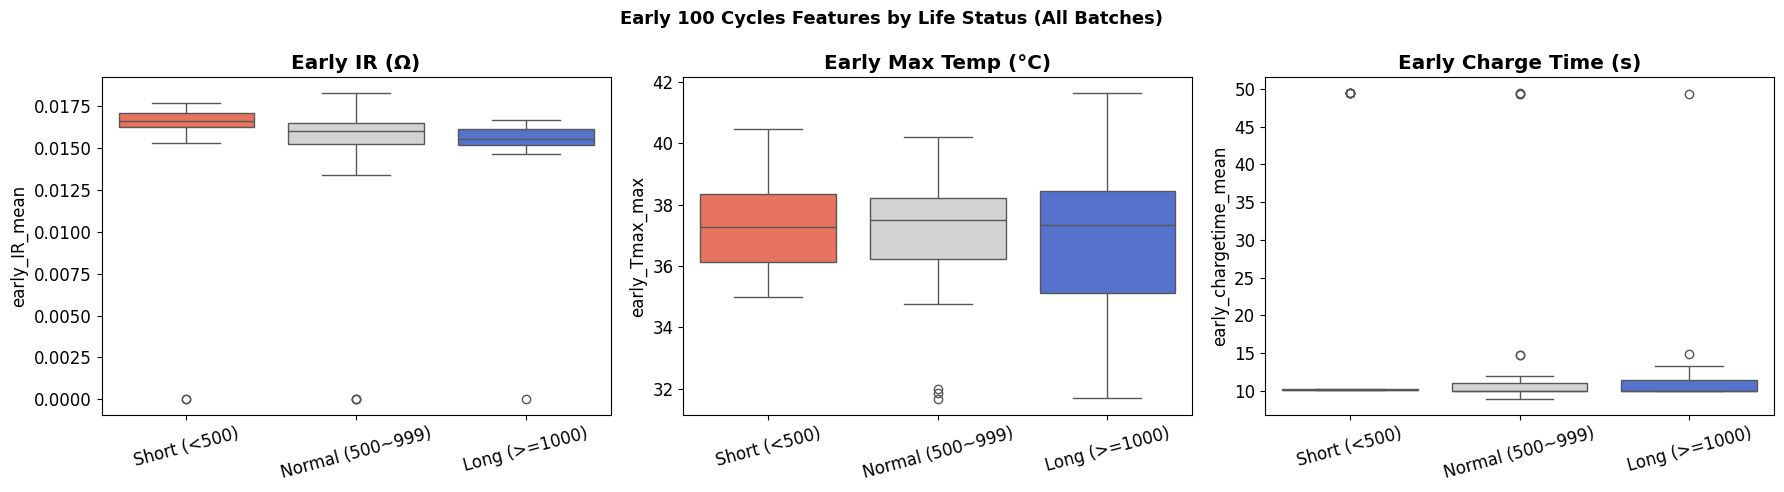

In [47]:
early_features = df[df['cycle'] <= 100].groupby('cell_id').agg(
    early_IR_mean         = ('IR',         'mean'),
    early_Tmax_max        = ('Tmax',       'max'),
    early_chargetime_mean = ('chargetime', 'mean'),
).reset_index()

merged_life  = pd.merge(cycle_life_df, early_features, on='cell_id')
order_list   = ['Short (<500)', 'Normal (500~999)', 'Long (>=1000)']
palette_dict = {'Short (<500)': 'tomato', 'Normal (500~999)': 'lightgray',
                'Long (>=1000)': 'royalblue'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat, title in zip(axes,
    ['early_IR_mean', 'early_Tmax_max', 'early_chargetime_mean'],
    ['Early IR (Ω)', 'Early Max Temp (°C)', 'Early Charge Time (s)']):
    sns.boxplot(data=merged_life, x='Life_Status', y=feat,
                order=order_list, palette=palette_dict, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Early 100 Cycles Features by Life Status (All Batches)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"nominal : {nominal:.4f} Ah   |   필터 범위 : {lower:.4f} ~ {upper:.4f} Ah")
print(f"제거 행  : {len(df)-len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

nominal : 1.0767 Ah   |   필터 범위 : 0.8613 ~ 1.2920 Ah
제거 행  : 698 (0.64%)


### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

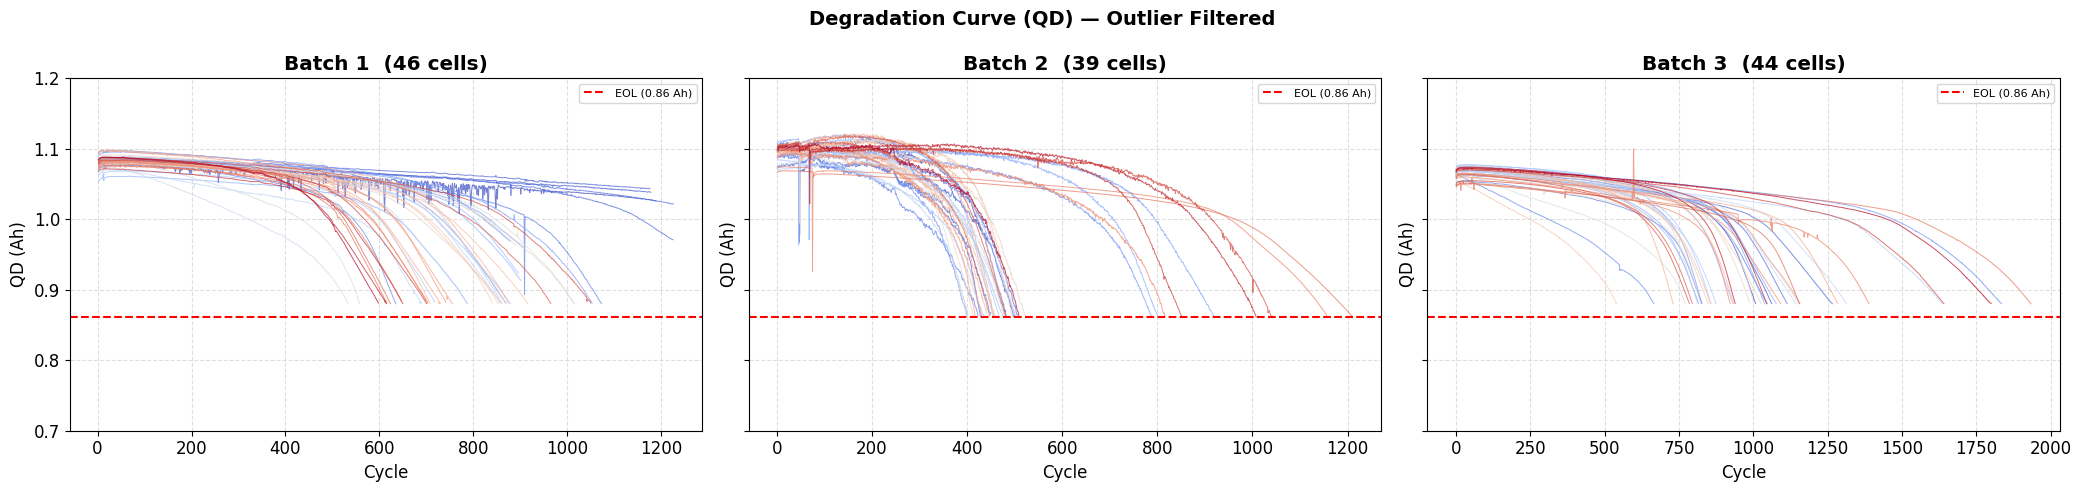

In [49]:
fig, axes = plt.subplots(1, len(all_batches), figsize=(7*len(all_batches), 5), sharey=True)
if len(all_batches) == 1: axes = [axes]

for ax, (bid, batch) in zip(axes, sorted(all_batches.items())):
    sub_df = df_clean[df_clean['batch_id'] == bid]
    cids   = sub_df['cell_id'].unique()
    colors = cm.coolwarm(np.linspace(0, 1, len(cids)))

    for i, cid in enumerate(cids):
        sub = sub_df[sub_df['cell_id'] == cid]
        ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.7, alpha=0.7)

    ax.axhline(y=nominal * 0.8, color='red', linestyle='--', linewidth=1.5,
               label=f'EOL ({nominal*0.8:.2f} Ah)')
    ax.set_title(f'Batch {bid}  ({len(cids)} cells)', fontweight='bold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QD (Ah)')
    ax.set_ylim(0.7, 1.2)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Degradation Curve (QD) — Outlier Filtered', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Knee Point 탐색

In [50]:
SG_WINDOW    = 21
SG_POLYORDER = 3
MIN_CYCLE    = 50
MAX_CYCLE_R  = 0.95
MARGIN       = 20

def sg_smooth(arr, window=SG_WINDOW, poly=SG_POLYORDER):
    w = min(window, len(arr))
    if w % 2 == 0: w -= 1
    if w < poly + 2: return arr
    return savgol_filter(arr, window_length=w, polyorder=poly)

def find_knee_piecewise(x, y_smooth, min_cycle=MIN_CYCLE,
                         max_cycle_ratio=MAX_CYCLE_R, margin=MARGIN):
    n         = len(x)
    start_idx = np.searchsorted(x, min_cycle)
    end_idx   = int(n * max_cycle_ratio)
    best_idx, best_err = start_idx + margin, np.inf
    for k in range(start_idx + margin, end_idx - margin):
        x1, y1 = x[:k], y_smooth[:k]
        x2, y2 = x[k:], y_smooth[k:]
        p1, p2 = np.polyfit(x1, y1, 1), np.polyfit(x2, y2, 1)
        err = (np.sum((y1 - np.polyval(p1, x1))**2) +
               np.sum((y2 - np.polyval(p2, x2))**2))
        if err < best_err:
            best_err, best_idx = err, k
    return best_idx

knee_records = []
for cid in df_clean['cell_id'].unique():
    sub = df_clean[df_clean['cell_id'] == cid].sort_values('cycle').reset_index(drop=True)
    x, qd = sub['cycle'].values, sub['QD'].values
    if len(x) < MIN_CYCLE + 2 * MARGIN:
        continue
    qd_s  = sg_smooth(qd)
    k_idx = find_knee_piecewise(x, qd_s)
    knee_records.append({
        'cell_id'    : cid,
        'batch_id'   : sub['batch_id'].iloc[0],
        'cycle_life' : sub['cycle_life'].iloc[0],
        'knee_cycle' : int(x[k_idx]),
        'knee_qd'    : float(qd_s[k_idx]),
    })

knee_df = pd.DataFrame(knee_records)
print(f"Knee Point 계산 완료 : {len(knee_df)} 셀")
print(knee_df.groupby('batch_id')[['knee_cycle', 'cycle_life']].describe().round(1))

Knee Point 계산 완료 : 129 셀
         knee_cycle                                                    \
              count   mean    std    min    25%    50%    75%     max   
batch_id                                                                
1              46.0  616.2  136.4  407.0  516.0  618.5  685.0   963.0   
2              39.0  430.7  184.5  249.0  321.0  348.0  390.5   948.0   
3              44.0  849.3  252.2  378.0  674.8  819.5  910.2  1523.0   

         cycle_life                                                       
              count    mean    std    min    25%     50%     75%     max  
batch_id                                                                  
1              46.0   844.7  184.6  534.0  703.2   858.5   914.2  1227.0  
2              39.0   565.7  222.2  392.0  439.5   472.0   508.5  1186.0  
3              44.0  1059.7  313.9  541.0  828.0  1005.5  1155.2  1935.0  


Knee vs Cycle Life 산점도

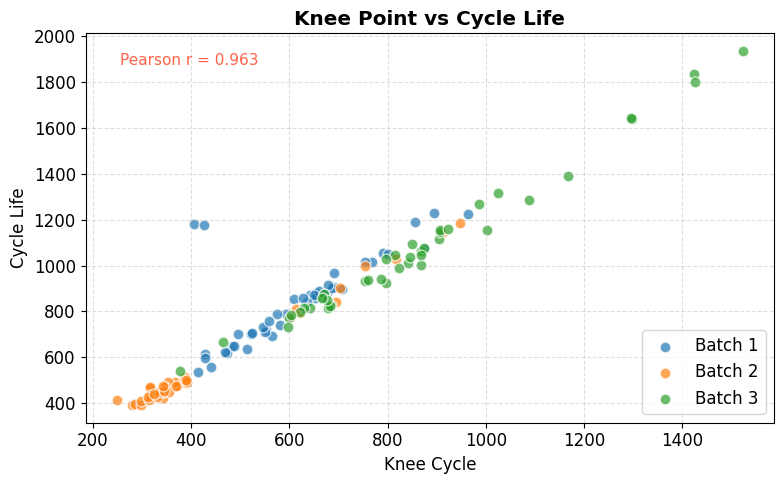

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
for bid in sorted(knee_df['batch_id'].unique()):
    sub = knee_df[knee_df['batch_id'] == bid]
    ax.scatter(sub['knee_cycle'], sub['cycle_life'], alpha=0.7,
               label=f'Batch {bid}', edgecolors='white', s=60)
ax.set_xlabel('Knee Cycle')
ax.set_ylabel('Cycle Life')
ax.set_title('Knee Point vs Cycle Life', fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
r = knee_df['knee_cycle'].corr(knee_df['cycle_life'])
ax.text(0.05, 0.95, f'Pearson r = {r:.3f}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', color='tomato')
plt.tight_layout()
plt.show()

In [52]:
CYCLE_A = 10
CYCLE_B = 100

def get_qdlin(batch, cell_local_idx, cycle_num):
    """batch list에서 특정 셀·사이클의 Qdlin 추출."""
    if cell_local_idx >= len(batch):
        return None
    cell_data  = batch[cell_local_idx]
    cycles_raw = cell_data.get('cycles')
    if cycles_raw is None:
        return None

    if isinstance(cycles_raw, dict):
        qdlin_list = cycles_raw.get('Qdlin', [])
        idx = cycle_num - 1
        if idx >= len(qdlin_list): return None
        val = qdlin_list[idx]
    else:
        idx = cycle_num - 1
        if idx >= len(cycles_raw): return None
        val = cycles_raw[idx].get('Qdlin')

    if val is None: return None
    arr = np.array(val).flatten()
    return arr if len(arr) > 0 else None


def get_vdlin(batch):
    """공통 전압 구간(Vdlin) 추출."""
    vd = batch[0].get('Vdlin')
    return np.array(vd).flatten() if vd is not None else None

 3. ΔQ(V) 전체 시각화

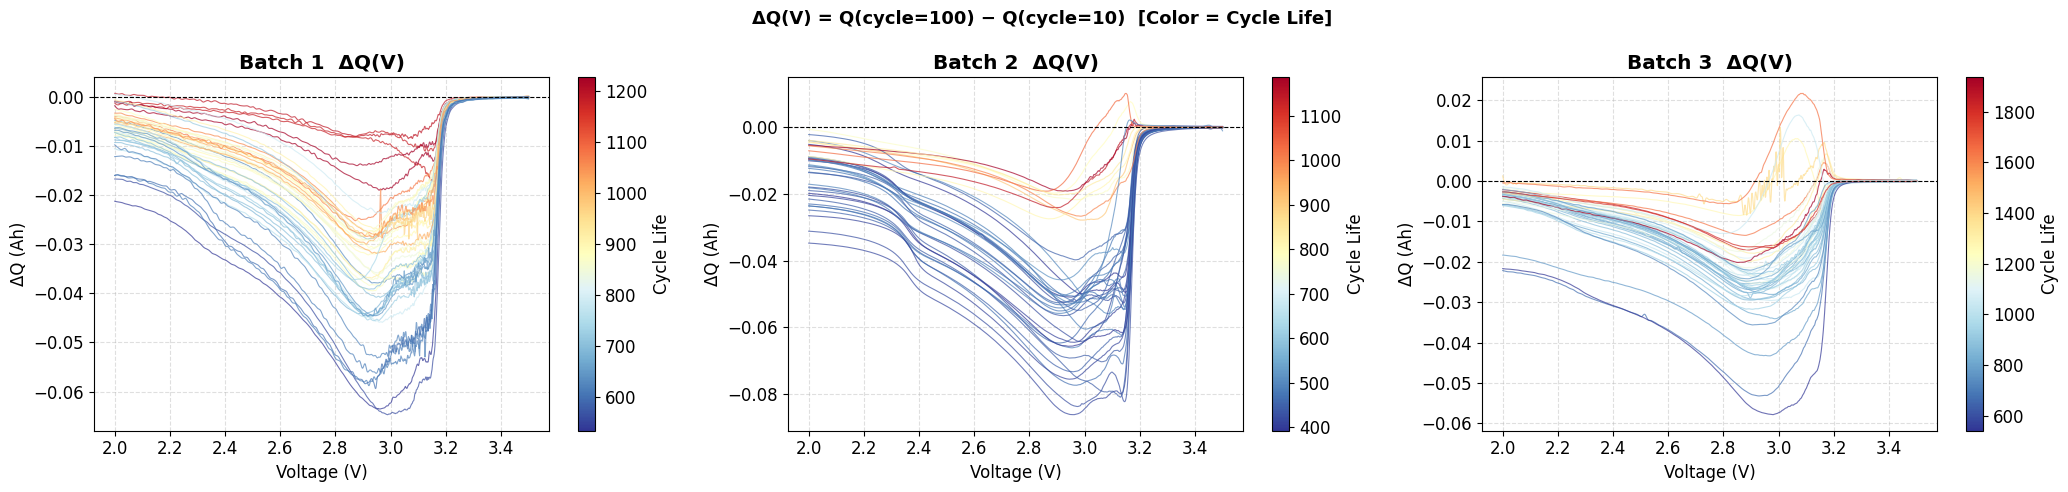

In [53]:
fig, axes = plt.subplots(1, len(all_batches), figsize=(7*len(all_batches), 5))
if len(all_batches) == 1: axes = [axes]

for ax, (bid, batch) in zip(axes, sorted(all_batches.items())):
    vdlin     = get_vdlin(batch)
    sub_cells = cycle_life_df[cycle_life_df['batch_id'] == bid]

    all_lives = sub_cells['cycle_life'].values
    cmap = cm.RdYlBu_r
    norm = mcolors.Normalize(vmin=all_lives.min(), vmax=all_lives.max())

    for _, row in sub_cells.iterrows():
        lid = int(row['local_cell_id'])
        q_a = get_qdlin(batch, lid, CYCLE_A)
        q_b = get_qdlin(batch, lid, CYCLE_B)
        if q_a is None or q_b is None: continue

        min_len = min(len(q_a), len(q_b),
                      len(vdlin) if vdlin is not None else 9999)
        v  = vdlin[:min_len] if vdlin is not None else np.arange(min_len)
        dq = q_b[:min_len] - q_a[:min_len]
        ax.plot(v, dq, color=cmap(norm(row['cycle_life'])),
                linewidth=0.8, alpha=0.7)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Cycle Life')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Batch {bid}  ΔQ(V)', fontweight='bold')
    ax.set_xlabel('Voltage (V)' if vdlin is not None else 'Voltage index')
    ax.set_ylabel('ΔQ (Ah)')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'ΔQ(V) = Q(cycle={CYCLE_B}) − Q(cycle={CYCLE_A})  [Color = Cycle Life]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. 내부 저항(IR) 변화 - 열화 지표

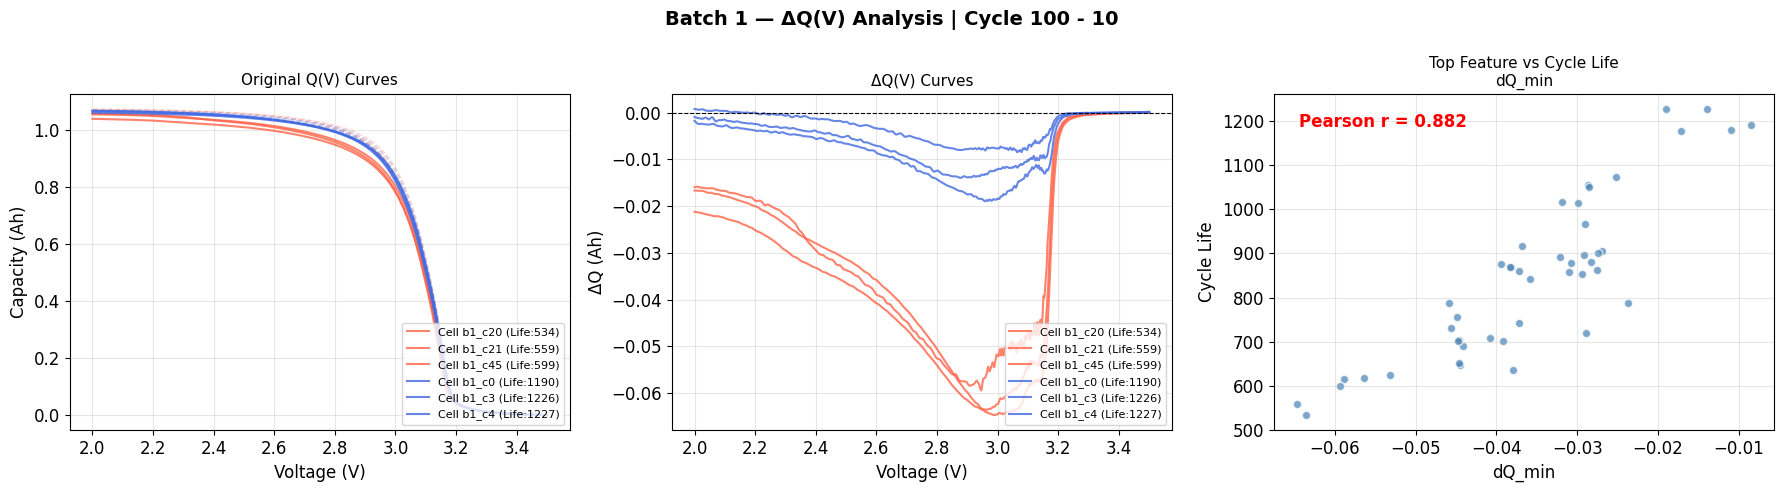


[Batch 1] ΔQ Features vs Cycle Life Correlation
dQ_min     0.8816
dQ_mean    0.8538
dQ_var    -0.8378
dQ_skew   -0.5850
dQ_kurt    0.3041

[Batch 1] Feature DataFrame (Total: 46 cells)
  cell_id  cycle_life    dQ_var    dQ_min
0   b1_c0        1190  0.000010 -0.008460
1   b1_c1        1179  0.000010 -0.011004
2   b1_c2        1177  0.000018 -0.017216
3   b1_c3        1226  0.000036 -0.018961
4   b1_c4        1227  0.000023 -0.013958


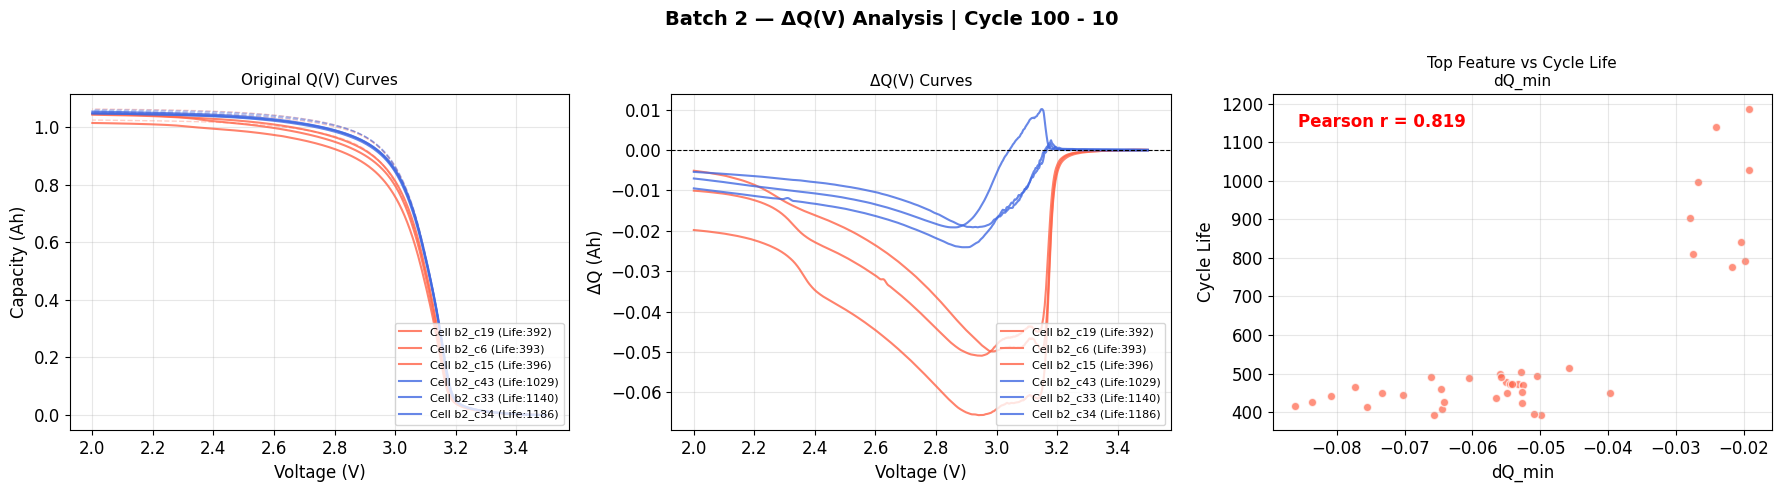


[Batch 2] ΔQ Features vs Cycle Life Correlation
dQ_min     0.8185
dQ_mean    0.7671
dQ_var    -0.7328
dQ_kurt    0.6482
dQ_skew   -0.1019

[Batch 2] Feature DataFrame (Total: 39 cells)
  cell_id  cycle_life    dQ_var    dQ_min
0   b2_c0         477  0.000326 -0.055061
1   b2_c1         491  0.000503 -0.066115
2   b2_c2         424  0.000347 -0.052718
3   b2_c3         499  0.000319 -0.055868
4   b2_c4         444  0.000585 -0.070297


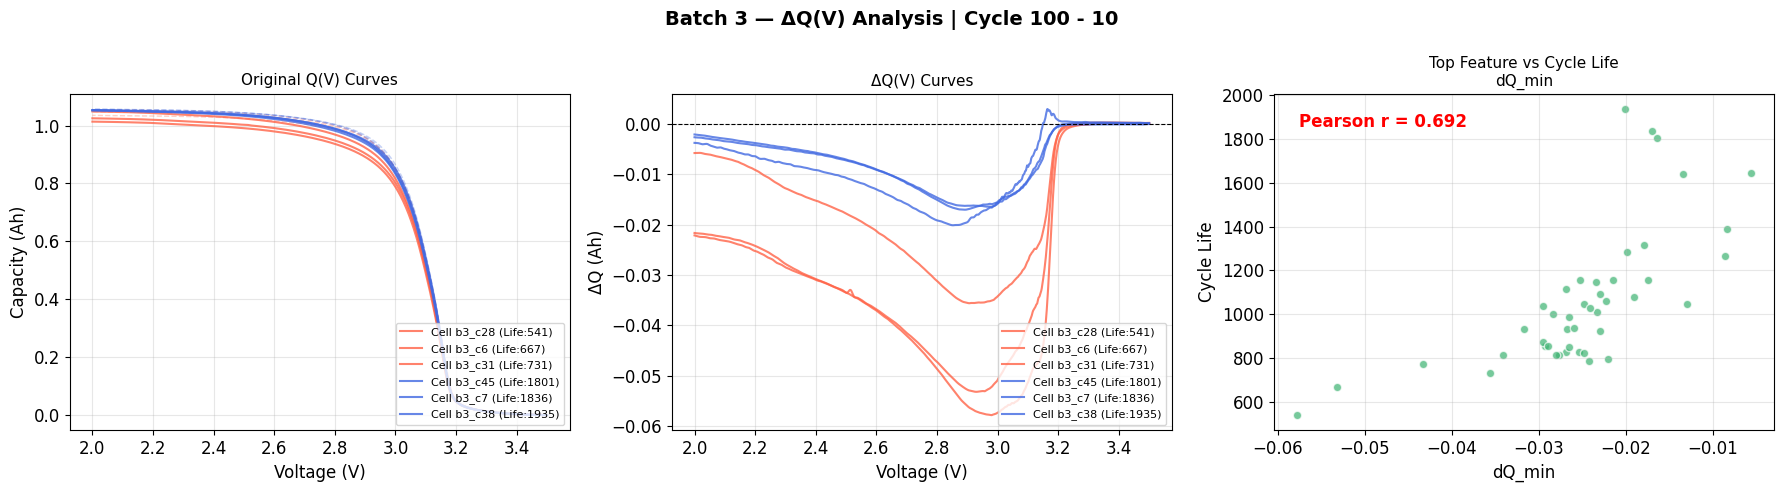


[Batch 3] ΔQ Features vs Cycle Life Correlation
dQ_min     0.6921
dQ_mean    0.6391
dQ_var    -0.5897
dQ_kurt    0.3299
dQ_skew    0.2102

[Batch 3] Feature DataFrame (Total: 44 cells)
  cell_id  cycle_life    dQ_var    dQ_min
0   b3_c0        1009  0.000057 -0.023312
1   b3_c1        1063  0.000052 -0.022324
2   b3_c2        1267  0.000017 -0.008648
3   b3_c3        1115  0.000076 -0.026837
4   b3_c4        1048  0.000066 -0.024810


In [54]:
CYCLE_A = 10
CYCLE_B = 100

batch_ids    = sorted(all_batches.keys())
batch_colors = {1: 'steelblue', 2: 'tomato', 3: 'mediumseagreen'}

# ── 1. ΔQ(V) 시각화 — 배치별 ─────────────────────────────────────────────
for bid in batch_ids:
    batch     = all_batches[bid]
    vdlin     = get_vdlin(batch)
    x_label   = 'Voltage (V)' if vdlin is not None else 'Voltage Index'

    # 해당 배치 셀만 필터링
    sub_clean = df_clean[df_clean['batch_id'] == bid]
    cycle_life_summary = sub_clean.groupby('cell_id')['cycle_life'].first().sort_values()
    short_cells  = cycle_life_summary.head(3).index.tolist()
    long_cells   = cycle_life_summary.tail(3).index.tolist()
    sample_cells = short_cells + long_cells

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Batch {bid} — ΔQ(V) Analysis | Cycle {CYCLE_B} - {CYCLE_A}',
                 fontsize=14, fontweight='bold')

    color_map = {'short': 'tomato', 'long': 'royalblue'}

    for cid in sample_cells:
        is_short = cid in short_cells
        color    = color_map['short'] if is_short else color_map['long']
        life     = cycle_life_summary[cid]
        label    = f'Cell {cid} (Life:{int(life)})'

        # local_cell_id 추출
        row = cycle_life_df[cycle_life_df['cell_id'] == cid]
        if len(row) == 0: continue
        lid = int(row['local_cell_id'].iloc[0])

        q_a = get_qdlin(batch, lid, CYCLE_A)
        q_b = get_qdlin(batch, lid, CYCLE_B)
        if q_a is None or q_b is None: continue

        min_len = min(len(q_a), len(q_b))
        if vdlin is not None:
            min_len = min(min_len, len(vdlin))
            x_axis  = vdlin[:min_len]
        else:
            x_axis  = np.arange(min_len)

        q_a, q_b = q_a[:min_len], q_b[:min_len]
        dq = q_b - q_a

        axes[0].plot(x_axis, q_a, color=color, lw=1,   alpha=0.3, ls='--')
        axes[0].plot(x_axis, q_b, color=color, lw=1.5, alpha=0.8, label=label)
        axes[1].plot(x_axis, dq,  color=color, lw=1.5, alpha=0.8, label=label)

    axes[0].set_title('Original Q(V) Curves', fontsize=11)
    axes[0].set_xlabel(x_label); axes[0].set_ylabel('Capacity (Ah)')
    axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(True, alpha=0.3)

    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[1].set_title('ΔQ(V) Curves', fontsize=11)
    axes[1].set_xlabel(x_label); axes[1].set_ylabel('ΔQ (Ah)')
    axes[1].legend(fontsize=8, loc='lower right'); axes[1].grid(True, alpha=0.3)

    # ── 2. ΔQ 통계 피처 추출 ─────────────────────────────────────
    feature_records = []
    for cid in sub_clean['cell_id'].unique():
        life = sub_clean[sub_clean['cell_id'] == cid]['cycle_life'].iloc[0]
        row  = cycle_life_df[cycle_life_df['cell_id'] == cid]
        if len(row) == 0: continue
        lid  = int(row['local_cell_id'].iloc[0])

        q_a = get_qdlin(batch, lid, CYCLE_A)
        q_b = get_qdlin(batch, lid, CYCLE_B)
        if q_a is None or q_b is None: continue

        min_len = min(len(q_a), len(q_b))
        dq      = q_b[:min_len] - q_a[:min_len]

        feature_records.append({
            'cell_id'      : cid,
            'cycle_life'   : life,
            'log_cycle_life': np.log10(life),
            'dQ_mean'      : np.mean(dq),
            'dQ_var'       : np.var(dq),
            'dQ_min'       : np.min(dq),
            'dQ_skew'      : pd.Series(dq).skew(),
            'dQ_kurt'      : pd.Series(dq).kurt(),
        })

    feat_df = pd.DataFrame(feature_records)
    if feat_df.empty:
        print(f"Batch {bid}: ΔQ 피처 추출 실패")
        plt.show()
        continue

    corr     = (feat_df.drop(columns=['cell_id'])
                .corr()['cycle_life']
                .drop(['cycle_life', 'log_cycle_life'])
                .sort_values(key=abs, ascending=False))
    top_feat = corr.index[0]

    axes[2].scatter(feat_df[top_feat], feat_df['cycle_life'],
                    alpha=0.7, color=batch_colors.get(bid, 'teal'),
                    edgecolors='white')
    axes[2].set_title(f'Top Feature vs Cycle Life\n{top_feat}', fontsize=11)
    axes[2].set_xlabel(top_feat); axes[2].set_ylabel('Cycle Life')
    r = feat_df[top_feat].corr(feat_df['cycle_life'])
    axes[2].text(0.05, 0.9, f'Pearson r = {r:.3f}',
                 transform=axes[2].transAxes, color='red', fontweight='bold')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n[Batch {bid}] ΔQ Features vs Cycle Life Correlation")
    print(corr.round(4).to_string())
    print(f"\n[Batch {bid}] Feature DataFrame (Total: {len(feat_df)} cells)")
    print(feat_df[['cell_id', 'cycle_life', 'dQ_var', 'dQ_min']].head())

In [ ]:
def extract_first_crate(policy):
    matches = re.findall(r'(\d+\.?\d*)C', str(policy))
    return float(matches[0]) if matches else np.nan

def extract_threshold(policy):
    match = re.search(r'\((\d+)%\)', str(policy))
    return float(match.group(1)) if match else np.nan

def extract_second_crate(policy):
    matches = re.findall(r'(\d+\.?\d*)C', str(policy))
    return float(matches[1]) if len(matches) >= 2 else np.nan

cycle_life_df['first_crate']   = cycle_life_df['charging_policy'].apply(extract_first_crate)
cycle_life_df['threshold_pct'] = cycle_life_df['charging_policy'].apply(extract_threshold)
cycle_life_df['second_crate']  = cycle_life_df['charging_policy'].apply(extract_second_crate)

print("C-rate 추출 완료")
print(cycle_life_df[['charging_policy','first_crate','threshold_pct','second_crate']].head(10))


NameError: name 'cycle_life_df' is not defined

### 4. 충전 정책(C-rate)과 수명의 관계

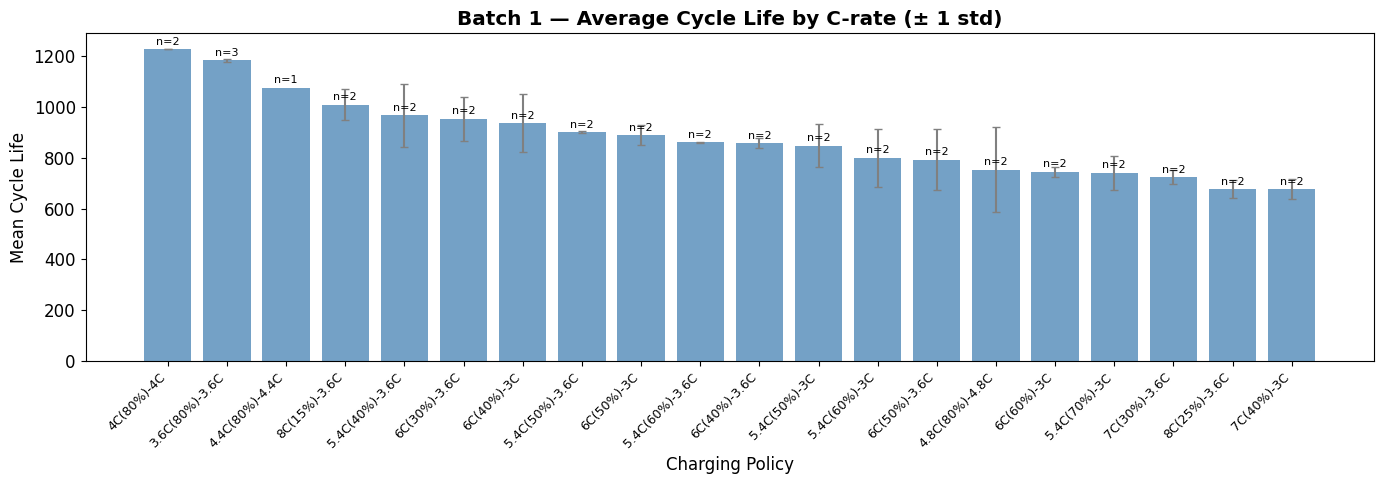

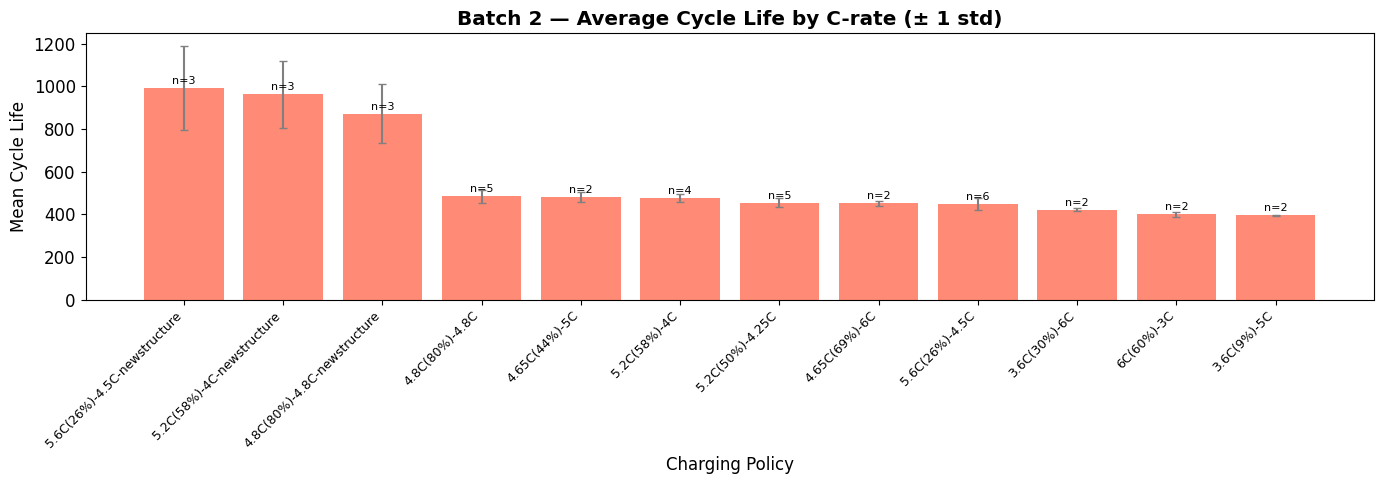

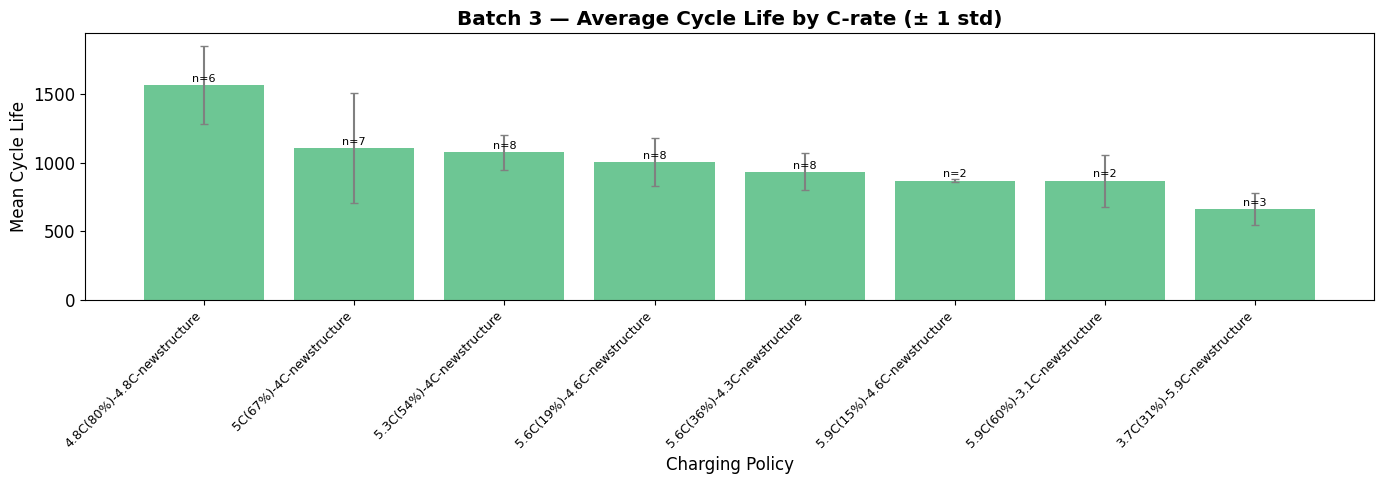

In [56]:
policy_life = (
    cycle_life_df.groupby(['batch_id', 'charging_policy'])['cycle_life']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

for bid in sorted(cycle_life_df['batch_id'].unique()):
    sub = policy_life[policy_life['batch_id'] == bid].head(20)
    if len(sub) == 0: continue

    fig, ax = plt.subplots(figsize=(14, 5))
    x    = range(len(sub))
    bars = ax.bar(x, sub['mean'], yerr=sub['std'],
                  color=batch_colors.get(bid, 'steelblue'), alpha=0.75,
                  error_kw=dict(ecolor='gray', capsize=3))
    ax.set_xticks(x)
    ax.set_xticklabels(sub['charging_policy'], rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Charging Policy')
    ax.set_ylabel('Mean Cycle Life')
    ax.set_title(f'Batch {bid} — Average Cycle Life by C-rate (± 1 std)',
                 fontweight='bold')
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

고속 vs 저속 충전 그룹 수명 비교 

Median first_crate : 5.4C
                      count    mean    std    min     25%     50%     75%  \
batch_id crate_group                                                        
1        High-rate     38.0   796.8  139.2  534.0   702.2   815.0   888.2   
         Low-rate       8.0  1072.4  212.1  636.0  1023.0  1178.0  1199.0   
2        High-rate     11.0   587.7  275.3  392.0   418.5   450.0   641.0   
         Low-rate      28.0   557.1  202.8  393.0   447.8   474.0   505.8   
3        High-rate     20.0   946.2  150.3  731.0   825.2   899.5  1059.2   
         Low-rate      24.0  1154.2  380.8  541.0   908.2  1054.5  1333.8   

                         max  
batch_id crate_group          
1        High-rate    1054.0  
         Low-rate     1227.0  
2        High-rate    1186.0  
         Low-rate     1140.0  
3        High-rate    1267.0  
         Low-rate     1935.0  


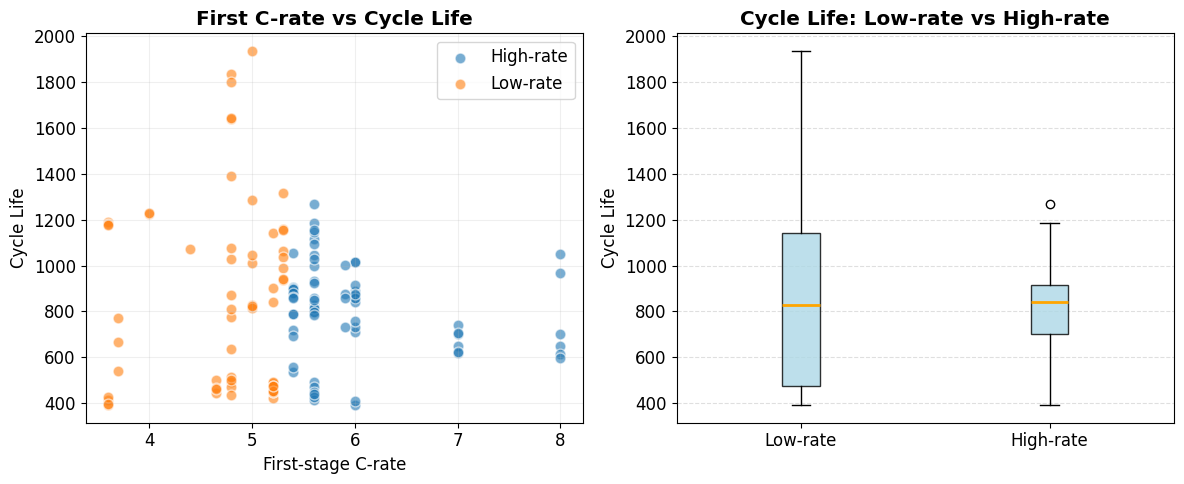

In [57]:
median_crate = cycle_life_df['first_crate'].median()
cycle_life_df['crate_group'] = np.where(
    cycle_life_df['first_crate'] >= median_crate, 'High-rate', 'Low-rate')

print(f"Median first_crate : {median_crate}C")
print(cycle_life_df.groupby(['batch_id', 'crate_group'])['cycle_life'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for gname, gdf in cycle_life_df.groupby('crate_group'):
    axes[0].scatter(gdf['first_crate'], gdf['cycle_life'],
                    alpha=0.6, edgecolors='white', s=60, label=gname)
axes[0].set_xlabel('First-stage C-rate')
axes[0].set_ylabel('Cycle Life')
axes[0].set_title('First C-rate vs Cycle Life', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.2)

grp_data = [
    cycle_life_df[cycle_life_df['crate_group']=='Low-rate']['cycle_life'],
    cycle_life_df[cycle_life_df['crate_group']=='High-rate']['cycle_life'],
]
axes[1].boxplot(grp_data, labels=['Low-rate', 'High-rate'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.8),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Cycle Life: Low-rate vs High-rate', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Median first_crate : 5.4C
                      count    mean    std    min     25%     50%     75%  \
batch_id crate_group                                                        
1        High-rate     38.0   796.8  139.2  534.0   702.2   815.0   888.2   
         Low-rate       8.0  1072.4  212.1  636.0  1023.0  1178.0  1199.0   
2        High-rate     11.0   587.7  275.3  392.0   418.5   450.0   641.0   
         Low-rate      28.0   557.1  202.8  393.0   447.8   474.0   505.8   
3        High-rate     20.0   946.2  150.3  731.0   825.2   899.5  1059.2   
         Low-rate      24.0  1154.2  380.8  541.0   908.2  1054.5  1333.8   

                         max  
batch_id crate_group          
1        High-rate    1054.0  
         Low-rate     1227.0  
2        High-rate    1186.0  
         Low-rate     1140.0  
3        High-rate    1267.0  
         Low-rate     1935.0  


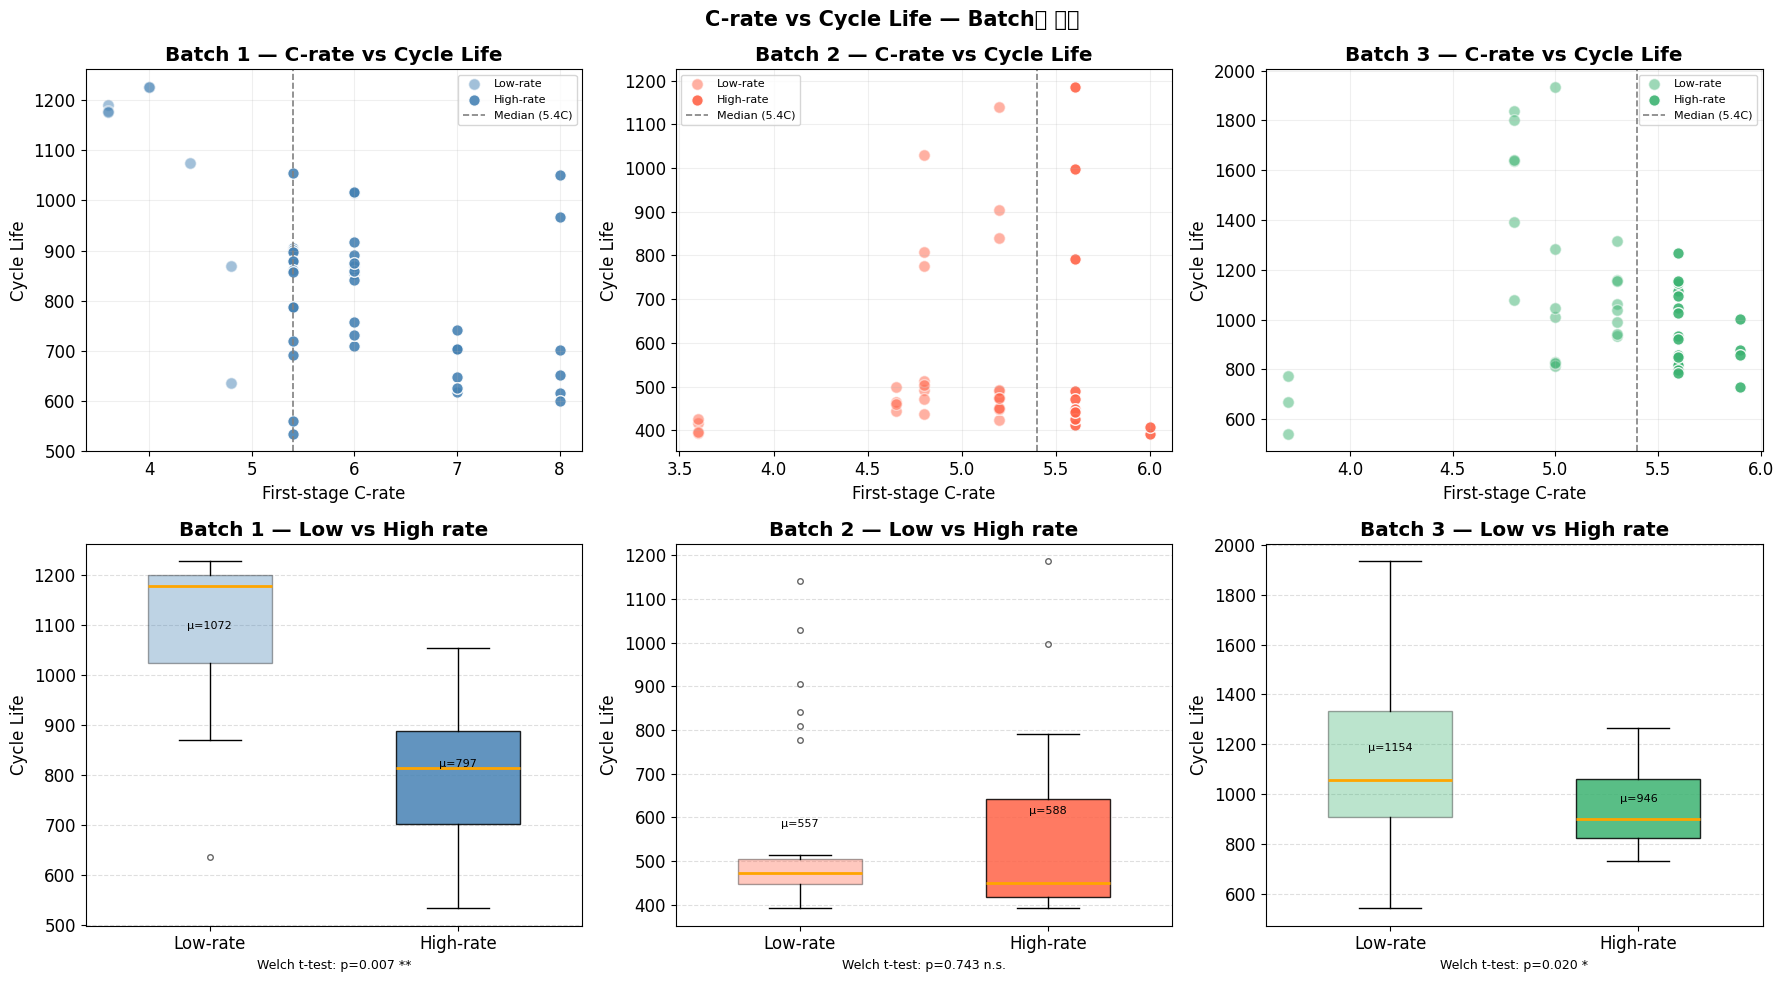

In [58]:
median_crate = cycle_life_df['first_crate'].median()
cycle_life_df['crate_group'] = np.where(
    cycle_life_df['first_crate'] >= median_crate, 'High-rate', 'Low-rate')

batch_ids    = sorted(cycle_life_df['batch_id'].unique())
batch_colors = {1: 'steelblue', 2: 'tomato', 3: 'mediumseagreen'}
n_batches    = len(batch_ids)

print(f"Median first_crate : {median_crate}C")
print(cycle_life_df.groupby(['batch_id', 'crate_group'])['cycle_life'].describe().round(1))

fig, axes = plt.subplots(2, n_batches, figsize=(6 * n_batches, 10))

for col, bid in enumerate(batch_ids):
    sub = cycle_life_df[cycle_life_df['batch_id'] == bid]
    color = batch_colors[bid]

    # ── 위: 산점도 ──────────────────────────────────────────────
    ax_sc = axes[0][col]
    for gname, alpha in [('Low-rate', 0.5), ('High-rate', 0.9)]:
        g = sub[sub['crate_group'] == gname]
        ax_sc.scatter(g['first_crate'], g['cycle_life'],
                      alpha=alpha, color=color,
                      edgecolors='white', s=70, label=gname)

    ax_sc.axvline(median_crate, color='gray', linestyle='--',
                  linewidth=1.2, label=f'Median ({median_crate}C)')
    ax_sc.set_xlabel('First-stage C-rate')
    ax_sc.set_ylabel('Cycle Life')
    ax_sc.set_title(f'Batch {bid} — C-rate vs Cycle Life', fontweight='bold')
    ax_sc.legend(fontsize=8)
    ax_sc.grid(alpha=0.2)

    # ── 아래: 박스플롯 ──────────────────────────────────────────
    ax_bp = axes[1][col]
    low_data  = sub[sub['crate_group'] == 'Low-rate']['cycle_life'].values
    high_data = sub[sub['crate_group'] == 'High-rate']['cycle_life'].values

    bp = ax_bp.boxplot(
        [low_data, high_data],
        labels=['Low-rate', 'High-rate'],
        patch_artist=True,
        medianprops=dict(color='orange', linewidth=2),
        flierprops=dict(marker='o', markersize=4, alpha=0.6),
        widths=0.5,
    )
    bp['boxes'][0].set_facecolor(color); bp['boxes'][0].set_alpha(0.35)
    bp['boxes'][1].set_facecolor(color); bp['boxes'][1].set_alpha(0.85)

    # 그룹별 평균 표시
    for i, (data, gname) in enumerate([(low_data, 'Low'), (high_data, 'High')], 1):
        if len(data) > 0:
            ax_bp.text(i, data.mean() + 20, f'μ={data.mean():.0f}',
                       ha='center', fontsize=8, color='black')

    ax_bp.set_ylabel('Cycle Life')
    ax_bp.set_title(f'Batch {bid} — Low vs High rate', fontweight='bold')
    ax_bp.grid(axis='y', linestyle='--', alpha=0.4)

    # t-test
    if len(low_data) > 1 and len(high_data) > 1:
        t, p = stats.ttest_ind(low_data, high_data, equal_var=False)
        sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        ax_bp.set_xlabel(f'Welch t-test: p={p:.3f} {sig}', fontsize=9)

plt.suptitle('C-rate vs Cycle Life — Batch별 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


 C-rate vs 열화 속도 상관 분석 


[Batch 1] C-rate vs Degradation Slope 상관계수
                   first_crate  degradation_slope
first_crate              1.000             -0.617
degradation_slope       -0.617              1.000

[Batch 2] C-rate vs Degradation Slope 상관계수
                   first_crate  degradation_slope
first_crate              1.000              0.265
degradation_slope        0.265              1.000

[Batch 3] C-rate vs Degradation Slope 상관계수
                   first_crate  degradation_slope
first_crate              1.000              0.349
degradation_slope        0.349              1.000


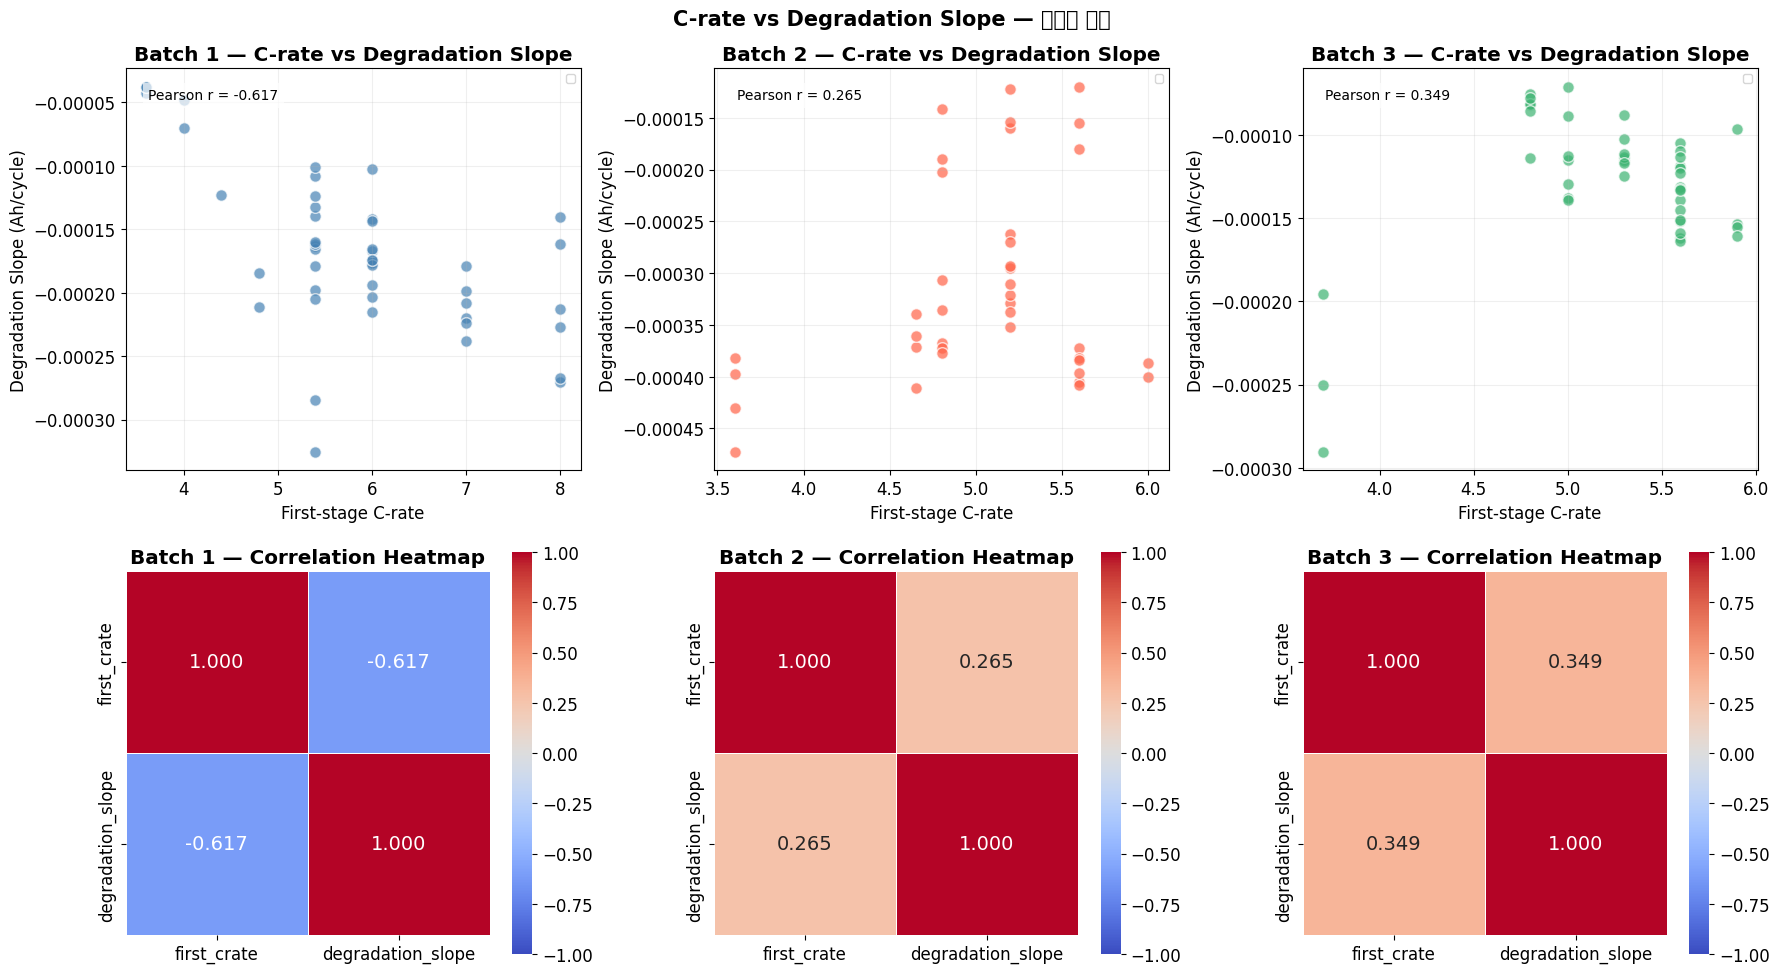

In [ ]:
deg_rows = []
for cid in df_clean['cell_id'].unique():
    sub = df_clean[df_clean['cell_id'] == cid].sort_values('cycle')
    if len(sub) < 50: continue
    x, y  = sub['cycle'].values, sub['QD'].values
    slope = np.polyfit(x, y, 1)[0]
    deg_rows.append({
        'cell_id'          : cid,
        'batch_id'         : sub['batch_id'].iloc[0],
        'cycle_life'       : sub['cycle_life'].iloc[0],
        'charging_policy'  : sub['charging_policy'].iloc[0],
        'degradation_slope': slope,
    })

deg_df = pd.DataFrame(deg_rows)
deg_df['first_crate'] = deg_df['charging_policy'].apply(extract_first_crate)

batch_ids    = sorted(deg_df['batch_id'].unique())
batch_colors = {1: 'steelblue', 2: 'tomato', 3: 'mediumseagreen'}
n_batches    = len(batch_ids)

fig, axes = plt.subplots(2, n_batches, figsize=(6 * n_batches, 10))
# batch가 1개일 때 axes 차원 통일
if n_batches == 1:
    axes = axes.reshape(2, 1)

for col, bid in enumerate(batch_ids):
    sub   = deg_df[deg_df['batch_id'] == bid].dropna(subset=['first_crate', 'degradation_slope'])
    color = batch_colors.get(bid, 'gray')

    # ── 위: 산점도 + 추세선 ─────────────────────────────────────
    ax_sc = axes[0][col]
    ax_sc.scatter(sub['first_crate'], sub['degradation_slope'],
                  alpha=0.7, color=color, edgecolors='white', s=70)

    r = sub['first_crate'].corr(sub['degradation_slope'])
    ax_sc.text(0.05, 0.95, f'Pearson r = {r:.3f}',
               transform=ax_sc.transAxes, fontsize=10,
               verticalalignment='top', color='black',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax_sc.set_xlabel('First-stage C-rate')
    ax_sc.set_ylabel('Degradation Slope (Ah/cycle)')
    ax_sc.set_title(f'Batch {bid} — C-rate vs Degradation Slope', fontweight='bold')
    ax_sc.legend(fontsize=8)
    ax_sc.grid(alpha=0.2)

    # ── 아래: 상관관계 히트맵 ───────────────────────────────────
    ax_hm = axes[1][col]
    corr_sub = sub[['first_crate', 'degradation_slope']].corr().round(3)
    sns.heatmap(corr_sub, ax=ax_hm, annot=True, fmt='.3f',
                cmap='coolwarm', vmin=-1, vmax=1, square=True,
                linewidths=0.5, annot_kws={'size': 14})
    ax_hm.set_title(f'Batch {bid} — Correlation Heatmap', fontweight='bold')

    print(f"\n[Batch {bid}] C-rate vs Degradation Slope 상관계수")
    print(corr_sub)

plt.suptitle('C-rate vs Degradation Slope — 배치별 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. 상관관계 히트맵

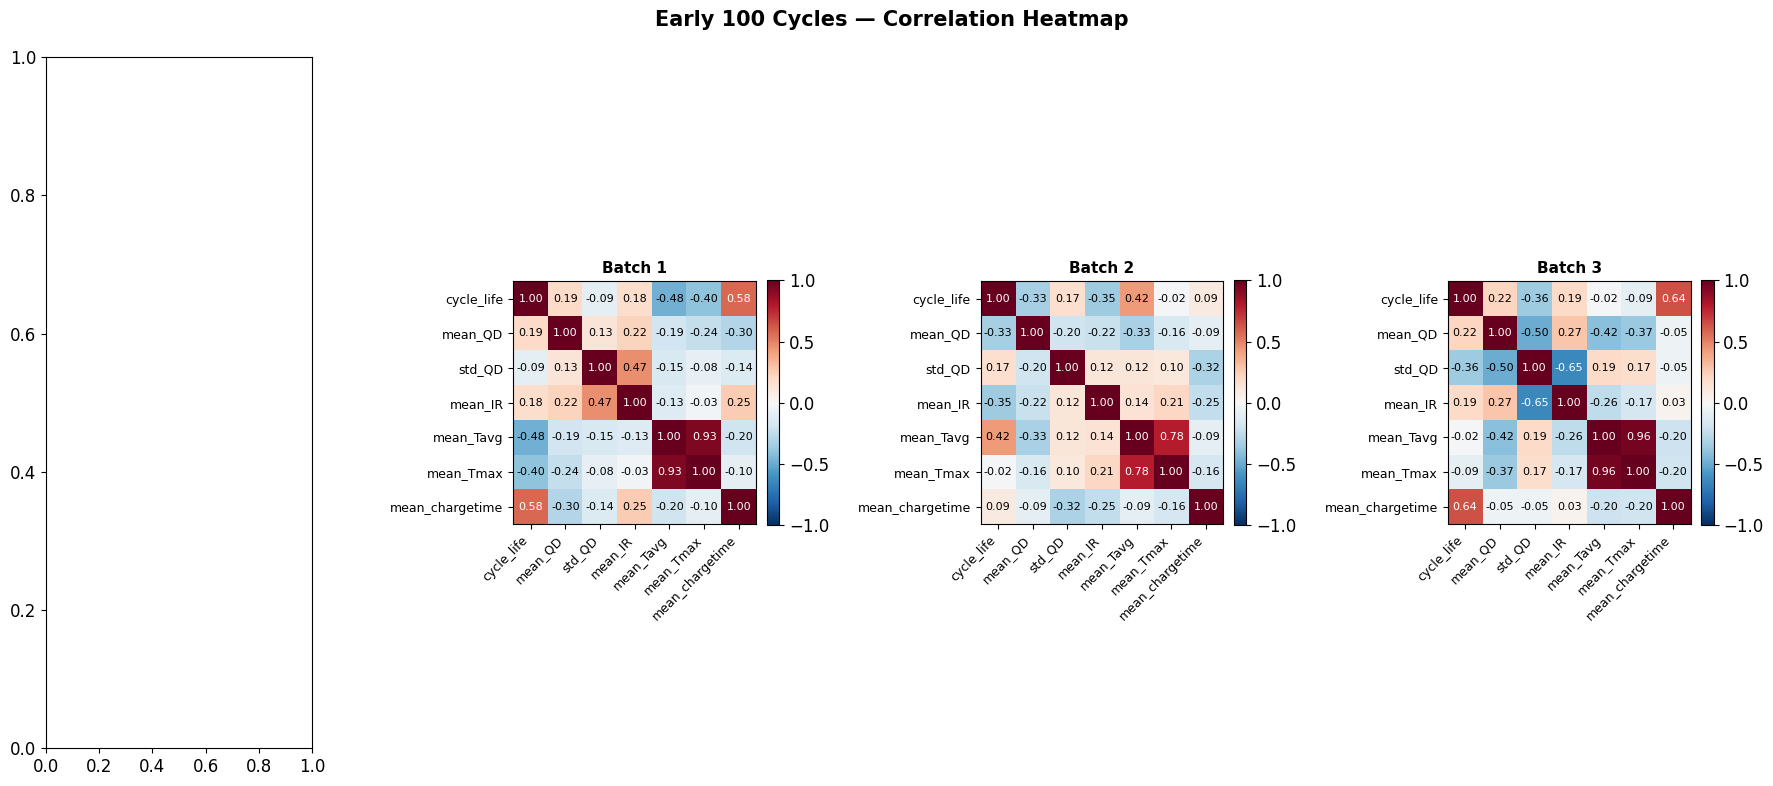


[cycle_life 상관계수 순위 — 배치별 비교]
                   All  Batch 1  Batch 2  Batch 3
mean_QD         -0.496    0.193   -0.332    0.217
mean_Tavg        0.225   -0.482    0.425   -0.022
mean_chargetime -0.194    0.577    0.087    0.637
mean_Tmax       -0.072   -0.400   -0.016   -0.090
std_QD           0.004   -0.090    0.171   -0.356
mean_IR          0.000    0.177   -0.353    0.190


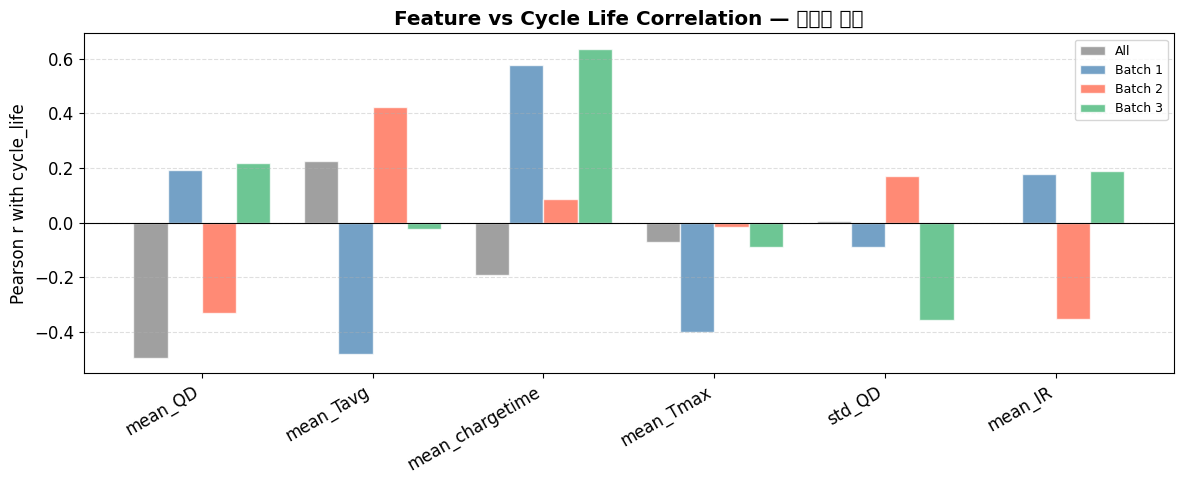

In [60]:
early_agg = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life',  'first'),
    batch_id        = ('batch_id',    'first'),
    mean_QD         = ('QD',         'mean'),
    std_QD          = ('QD',         'std'),
    mean_IR         = ('IR',         'mean'),
    mean_Tavg       = ('Tavg',       'mean'),
    mean_Tmax       = ('Tmax',       'max'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

batch_ids    = sorted(early_agg['batch_id'].unique())
batch_colors = {1: 'steelblue', 2: 'tomato', 3: 'mediumseagreen'}
n_batches    = len(batch_ids)

# ── 전체 통합 히트맵 + 배치별 히트맵 ─────────────────────────────────────
fig, axes = plt.subplots(1, n_batches + 1, figsize=(9 * (n_batches + 1) // 2, 8))
if n_batches == 0:
    axes = [axes]

def draw_heatmap(ax, corr_matrix, title):
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    labels = corr_matrix.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr_matrix.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if abs(val) > 0.5 else 'black')
    ax.set_title(title, fontsize=11, fontweight='bold')

# 배치별
for col, bid in enumerate(batch_ids, start=1):
    sub        = early_agg[early_agg['batch_id'] == bid].drop(columns=['batch_id'])
    corr_batch = sub.corr()
    draw_heatmap(axes[col], corr_batch, f'Batch {bid}')

plt.suptitle('Early 100 Cycles — Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── cycle_life 상관계수 순위 (배치별 비교 테이블) ─────────────────────────
print("\n" + "=" * 60)
print("[cycle_life 상관계수 순위 — 배치별 비교]")
print("=" * 60)

rank_df = pd.DataFrame()
rank_df['All'] = (corr_all['cycle_life']
                  .drop('cycle_life')
                  .sort_values(key=abs, ascending=False)
                  .round(3))

for bid in batch_ids:
    sub        = early_agg[early_agg['batch_id'] == bid].drop(columns=['batch_id'])
    corr_batch = sub.corr()
    rank_df[f'Batch {bid}'] = (corr_batch['cycle_life']
                                .drop('cycle_life')
                                .round(3))

print(rank_df.to_string())

# ── 배치별 상관계수 막대 비교 차트 ───────────────────────────────────────
feat_order = rank_df['All'].index.tolist()
x          = np.arange(len(feat_order))
n_cols     = len(rank_df.columns)  
width      = 0.8 / n_cols

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ['gray'] + [batch_colors.get(bid, 'skyblue') for bid in batch_ids]
for i, (col_name, col_color) in enumerate(zip(rank_df.columns, bar_colors)):
    vals = rank_df.loc[feat_order, col_name].values
    ax.bar(x + i * width, vals, width=width,
           color=col_color, alpha=0.75, edgecolor='white', label=col_name)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width * (n_cols - 1) / 2)
ax.set_xticklabels(feat_order, rotation=30, ha='right')
ax.set_ylabel('Pearson r with cycle_life')
ax.set_title('Feature vs Cycle Life Correlation — 배치별 비교', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [61]:
!pip install statsmodels -q

mean_Tmax 제거 완료 (mean_Tavg와 상관계수 ≈ 0.96, VIF 과다)

  VIF 비교 (배치별)


        feature  VIF_B1  VIF_B2  VIF_B3
        mean_QD 2601.17  689.73 2399.84
         std_QD   79.18    2.65    2.97
        mean_IR 1882.21    7.00  791.62
      mean_Tavg 1179.19  714.28  659.60
mean_chargetime   81.26    2.78  843.30
  ⚠ [B1] VIF > 10 : ['mean_QD', 'std_QD', 'mean_IR', 'mean_Tavg', 'mean_chargetime']
  ⚠ [B2] VIF > 10 : ['mean_QD', 'mean_Tavg']
  ⚠ [B3] VIF > 10 : ['mean_QD', 'mean_IR', 'mean_Tavg', 'mean_chargetime']

  잔존 피처 vs cycle_life 상관계수 (Pearson / Spearman)
                 Pearson_B1  Spearman_B1  Pearson_B2  Spearman_B2  Pearson_B3  Spearman_B3
mean_QD               0.193        0.185      -0.332        0.112       0.217        0.162
std_QD               -0.090        0.237       0.171       -0.113      -0.356       -0.355
mean_IR               0.177        0.136      -0.353       -0.346       0.190        0.169
mean_Tavg            -0.482       -0.371       0.425        0.176      -0.022        0.025
mean_chargetime       0.577        0.613       0.08

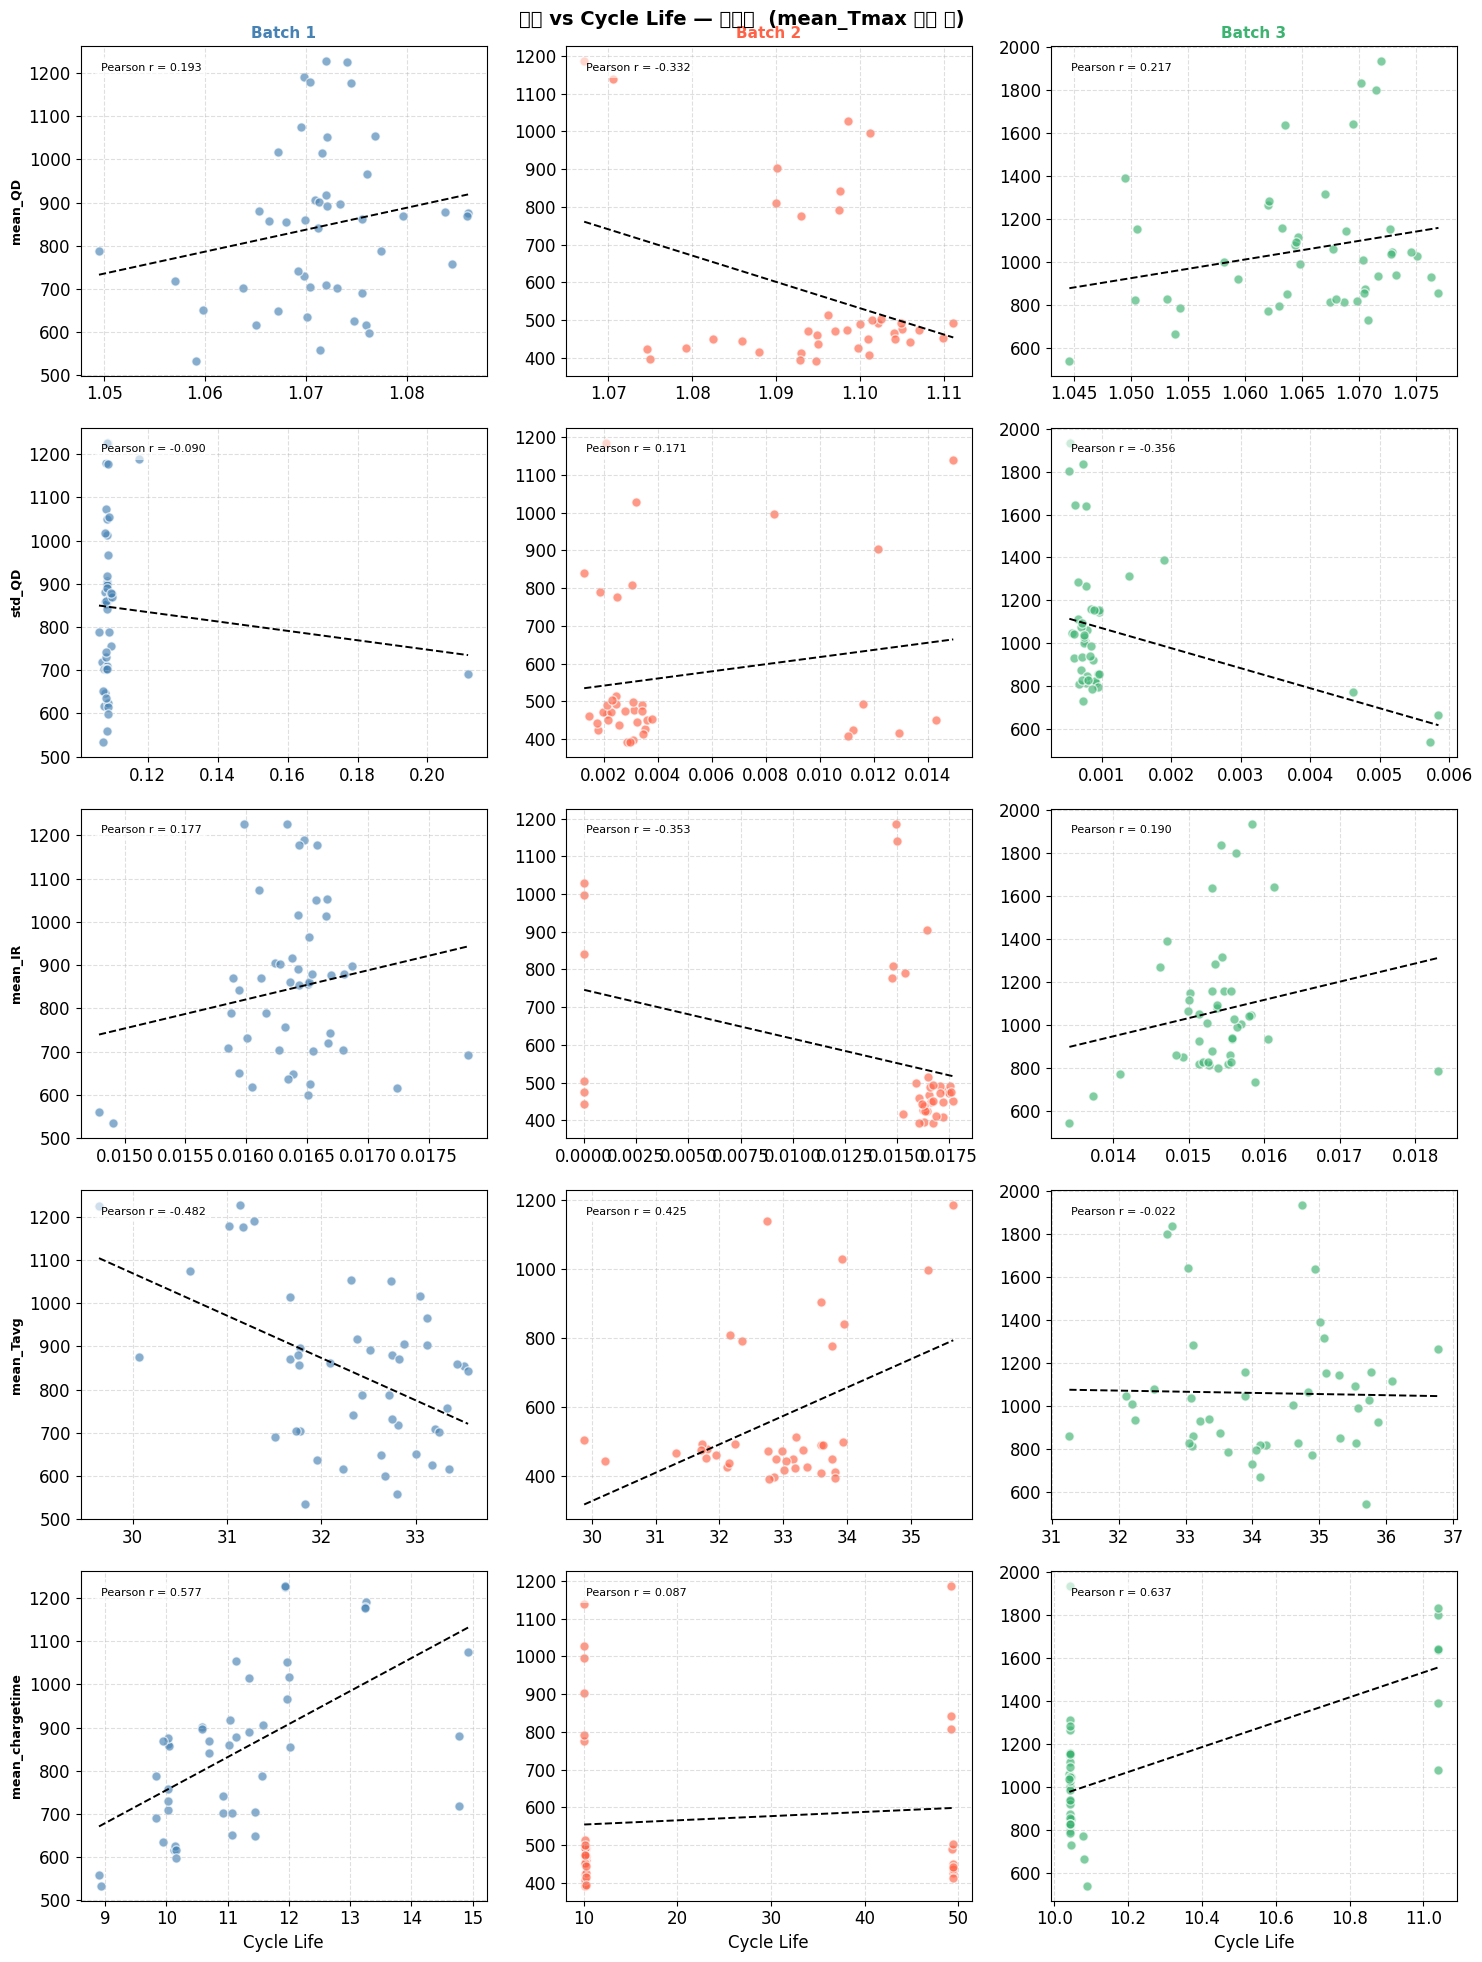

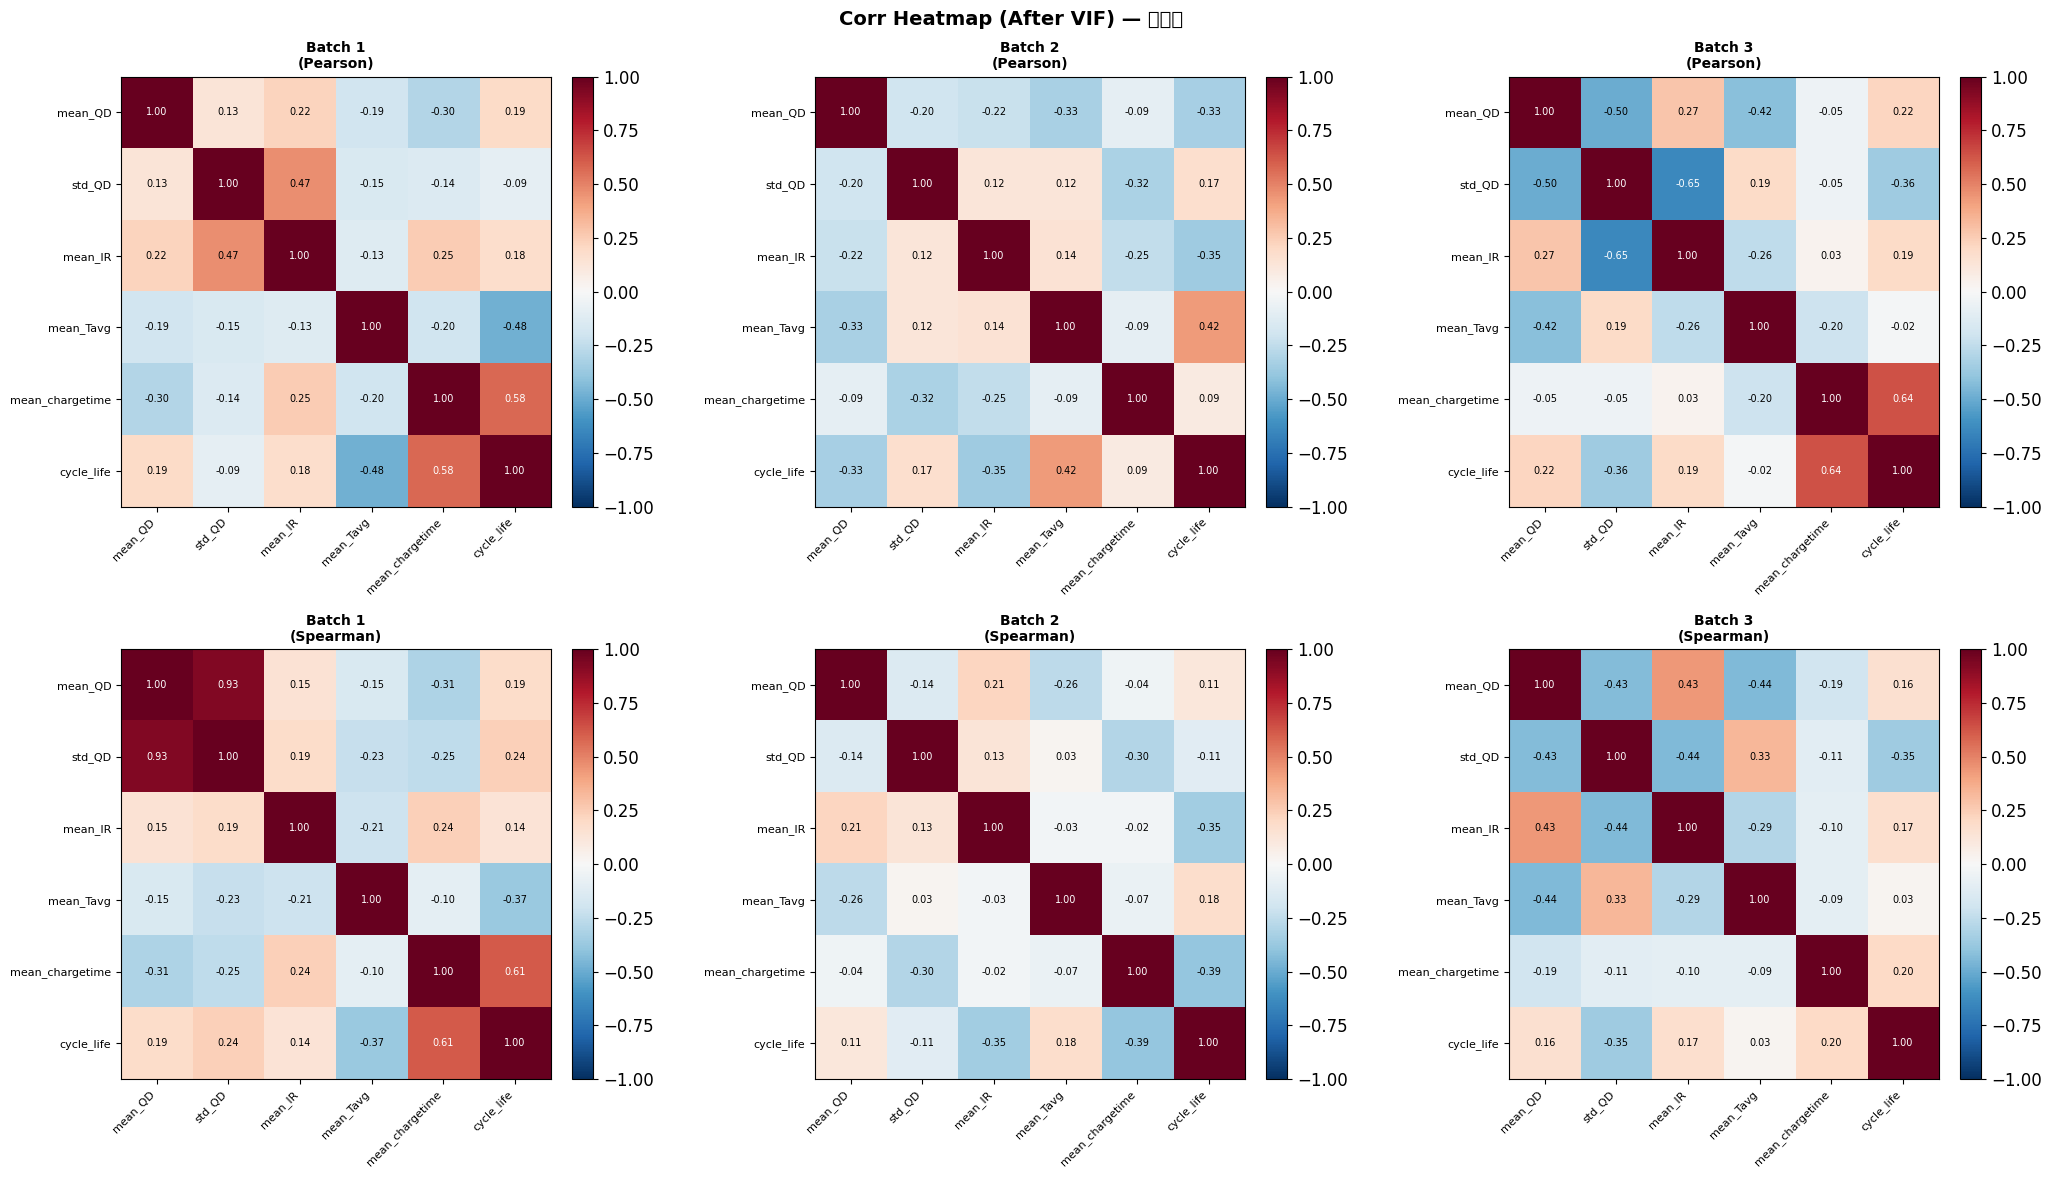

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

batch_ids    = sorted(df['batch_id'].unique())
batch_colors = {1: 'steelblue', 2: 'tomato', 3: 'mediumseagreen'}
feature_cols = ['mean_QD', 'std_QD', 'mean_IR', 'mean_Tavg', 'mean_chargetime']

# ── 1. 피처 집계 ─────────────────────────────────────────────────────────
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life',  'first'),
    batch_id        = ('batch_id',    'first'),
    mean_QD         = ('QD',         'mean'),
    std_QD          = ('QD',         'std'),
    mean_IR         = ('IR',         'mean'),
    mean_Tavg       = ('Tavg',       'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

print("mean_Tmax 제거 완료 (mean_Tavg와 상관계수 ≈ 0.96, VIF 과다)\n")


# ── 2. VIF — 배치별 ──────────────────────────────────────────────────────
def compute_vif(data, cols):
    X = data[cols].dropna()
    return pd.DataFrame({
        'feature': cols,
        'VIF'    : [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

print("=" * 55)
print("  VIF 비교 (배치별)")
print("=" * 55)

vif_merged = pd.DataFrame({'feature': feature_cols})
for bid in batch_ids:
    sub   = early[early['batch_id'] == bid]
    vif_b = compute_vif(sub, feature_cols).rename(columns={'VIF': f'VIF_B{bid}'})
    vif_merged = vif_merged.merge(vif_b, on='feature', how='left')

print(vif_merged.round(2).to_string(index=False))

for col in vif_merged.columns[1:]:
    flag  = vif_merged[vif_merged[col] > 10]['feature'].tolist()
    label = col.replace('VIF_', '')
    if flag:
        print(f"  ⚠ [{label}] VIF > 10 : {flag}")
    else:
        print(f"  ✔ [{label}] 모든 피처 VIF ≤ 10")


# ── 3. 상관계수 — 배치별 비교 테이블 ────────────────────────────────────
print("\n" + "=" * 55)
print("  잔존 피처 vs cycle_life 상관계수 (Pearson / Spearman)")
print("=" * 55)

def get_corr(data):
    d = data[feature_cols + ['cycle_life']].dropna()
    p = d.corr(method='pearson')['cycle_life'].drop('cycle_life').round(3)
    s = d.corr(method='spearman')['cycle_life'].drop('cycle_life').round(3)
    return p, s

corr_table = pd.DataFrame()
for bid in batch_ids:
    p_b, s_b = get_corr(early[early['batch_id'] == bid])
    corr_table[f'Pearson_B{bid}']  = p_b
    corr_table[f'Spearman_B{bid}'] = s_b

print(corr_table.to_string())


# ── 4. 산점도 — 배치별 subplot ───────────────────────────────────────────
n_feats   = len(feature_cols)
n_batches = len(batch_ids)

col_sources = [(f'Batch {bid}', early[early['batch_id'] == bid],
                batch_colors.get(bid, 'gray')) for bid in batch_ids]

fig, axes = plt.subplots(n_feats, n_batches,
                          figsize=(5 * n_batches, 4 * n_feats))
if n_batches == 1:
    axes = axes.reshape(n_feats, 1)

fig.suptitle('피처 vs Cycle Life — 배치별  (mean_Tmax 제거 후)',
             fontsize=14, fontweight='bold')

for row, feat in enumerate(feature_cols):
    for col, (label, data, color) in enumerate(col_sources):
        ax = axes[row][col]
        d  = data[['cycle_life', feat]].dropna()
        p_r = d[feat].corr(d['cycle_life'])

        ax.scatter(d[feat], d['cycle_life'],
                   alpha=0.65, color=color, edgecolors='white', s=45)

        if len(d) > 1:
            m, b   = np.polyfit(d[feat], d['cycle_life'], 1)
            x_line = np.linspace(d[feat].min(), d[feat].max(), 100)
            ax.plot(x_line, m * x_line + b,
                    color='black', linewidth=1.4, linestyle='--')

        ax.text(0.05, 0.95, f'Pearson r = {p_r:.3f}',
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top', color='black',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

        if row == 0:
            ax.set_title(label, fontsize=11, fontweight='bold', color=color)
        if col == 0:
            ax.set_ylabel(feat, fontsize=9, fontweight='bold')
        ax.set_xlabel('Cycle Life' if row == n_feats - 1 else '')
        ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# ── 5. 히트맵 — 배치별 (Pearson / Spearman 각 1행) ──────────────────────
fig, axes = plt.subplots(2, n_batches, figsize=(7 * n_batches, 12))
if n_batches == 1:
    axes = axes.reshape(2, 1)

fig.suptitle('Corr Heatmap (After VIF) — 배치별',
             fontsize=14, fontweight='bold')

def draw_heatmap(ax, data, title, method='pearson'):
    d      = data[feature_cols + ['cycle_life']].dropna()
    corr   = d.corr(method=method)
    labels = corr.columns.tolist()
    im     = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > 0.5 else 'black')
    ax.set_title(f'{title}\n({method.capitalize()})', fontsize=10, fontweight='bold')

for col, (label, data, _) in enumerate(col_sources):
    draw_heatmap(axes[0][col], data, label, method='pearson')
    draw_heatmap(axes[1][col], data, label, method='spearman')

plt.tight_layout()
plt.show()